## Problem Statement

### Business Context

Renewable energy sources play an increasingly important role in the global energy mix, as the effort to reduce the environmental impact of energy production increases.

Out of all the renewable energy alternatives, wind energy is one of the most developed technologies worldwide. The U.S Department of Energy has put together a guide to achieving operational efficiency using predictive maintenance practices.

Predictive maintenance uses sensor information and analysis methods to measure and predict degradation and future component capability. The idea behind predictive maintenance is that failure patterns are predictable and if component failure can be predicted accurately and the component is replaced before it fails, the costs of operation and maintenance will be much lower.

The sensors fitted across different machines involved in the process of energy generation collect data related to various environmental factors (temperature, humidity, wind speed, etc.) and additional features related to various parts of the wind turbine (gearbox, tower, blades, break, etc.).



## Objective
“ReneWind” is a company working on improving the machinery/processes involved in the production of wind energy using machine learning and has collected data of generator failure of wind turbines using sensors. They have shared a ciphered version of the data, as the data collected through sensors is confidential (the type of data collected varies with companies). Data has 40 predictors, 20000 observations in the training set and 5000 in the test set.

The objective is to build various classification models, tune them, and find the best one that will help identify failures so that the generators could be repaired before failing/breaking to reduce the overall maintenance cost.
The nature of predictions made by the classification model will translate as follows:

- True positives (TP) are failures correctly predicted by the model. These will result in repairing costs.
- False negatives (FN) are real failures where there is no detection by the model. These will result in replacement costs.
- False positives (FP) are detections where there is no failure. These will result in inspection costs.

It is given that the cost of repairing a generator is much less than the cost of replacing it, and the cost of inspection is less than the cost of repair.

“1” in the target variables should be considered as “failure” and “0” represents “No failure”.

## Data Description
- The data provided is a transformed version of original data which was collected using sensors.
- Train.csv - To be used for training and tuning of models.
- Test.csv - To be used only for testing the performance of the final best model.
- Both the datasets consist of 40 predictor variables and 1 target variable

## Importing necessary libraries

In [ ]:
# Use deprecated version of scikit-learn to address xgboost error using version 1.6:
!pip install scikit-learn==1.5.2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 50.1 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.0
    Uninstalling scikit-learn-1.6.0:
      Successfully uninstalled scikit-learn-1.6.0


**Note:** After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the start again.

In [ ]:
# Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np

# Libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# To tune model, get different metric scores, and split data
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay,
)
from sklearn import metrics

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score

# To be used for data scaling and one hot encoding
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder

# To impute missing values
from sklearn.impute import SimpleImputer

# To oversample and undersample data
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# To do hyperparameter tuning
from sklearn.model_selection import RandomizedSearchCV

# To be used for creating pipelines and personalizing them
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# To define maximum number of columns to be displayed in a dataframe
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

# To supress scientific notations for a dataframe
pd.set_option("display.float_format", lambda x: "%.3f" % x)

# To help with model building
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    AdaBoostClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
    BaggingClassifier,
)
from xgboost import XGBClassifier

# To suppress scientific notations
pd.set_option("display.float_format", lambda x: "%.3f" % x)

# To suppress warnings
import warnings

warnings.filterwarnings("ignore")

## Loading the dataset

In [ ]:
# Mount Google Colab:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Read in train data:
df = pd.read_csv("/content/drive/My Drive/Colab Notebooks/Model Tuning/Project/Train.csv")

# Read in test data:
df_test = pd.read_csv("/content/drive/My Drive/Colab Notebooks/Model Tuning/Project/Test.csv")

## Data Overview

- Observations
- Sanity checks

### Checking the shape of the dataset

In [ ]:
# Check the number of rows and columns in the training data:
print("The training data has {} rows and {} columns.".format(df.shape[0], df.shape[1]))

The training data has 20000 rows and 41 columns.


In [ ]:
# Check the number of rows and columns in the testing data:
print("The testing data has {} rows and {} columns.".format(df_test.shape[0], df_test.shape[1]))

The testing data has 5000 rows and 41 columns.


### Make copies of train and test datasets

In [ ]:
# Create Copy of train:
data = df.copy()

In [ ]:
# Create Copy of test:
data_test = df_test.copy()

### Check data types

In [ ]:
data.info(0)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 41 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   V1      19982 non-null  float64
 1   V2      19982 non-null  float64
 2   V3      20000 non-null  float64
 3   V4      20000 non-null  float64
 4   V5      20000 non-null  float64
 5   V6      20000 non-null  float64
 6   V7      20000 non-null  float64
 7   V8      20000 non-null  float64
 8   V9      20000 non-null  float64
 9   V10     20000 non-null  float64
 10  V11     20000 non-null  float64
 11  V12     20000 non-null  float64
 12  V13     20000 non-null  float64
 13  V14     20000 non-null  float64
 14  V15     20000 non-null  float64
 15  V16     20000 non-null  float64
 16  V17     20000 non-null  float64
 17  V18     20000 non-null  float64
 18  V19     20000 non-null  float64
 19  V20     20000 non-null  float64
 20  V21     20000 non-null  float64
 21  V22     20000 non-null  float64
 22

In [ ]:
# Check data types in test:
data_test.info(0)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 41 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   V1      4995 non-null   float64
 1   V2      4994 non-null   float64
 2   V3      5000 non-null   float64
 3   V4      5000 non-null   float64
 4   V5      5000 non-null   float64
 5   V6      5000 non-null   float64
 6   V7      5000 non-null   float64
 7   V8      5000 non-null   float64
 8   V9      5000 non-null   float64
 9   V10     5000 non-null   float64
 10  V11     5000 non-null   float64
 11  V12     5000 non-null   float64
 12  V13     5000 non-null   float64
 13  V14     5000 non-null   float64
 14  V15     5000 non-null   float64
 15  V16     5000 non-null   float64
 16  V17     5000 non-null   float64
 17  V18     5000 non-null   float64
 18  V19     5000 non-null   float64
 19  V20     5000 non-null   float64
 20  V21     5000 non-null   float64
 21  V22     5000 non-null   float64
 22  

In [ ]:
# Unique values for target in train:
data["Target"].unique()

array([0, 1])

In [ ]:
# Unique values for target in test:
data_test["Target"].unique()

array([0, 1])

* All variables are numeric
* Both train and test have null values for V1 and V2.
* The target variable has no null values and is indeed 0 or 1 (with 1 meaning failure).

### Checking for duplicate values

In [ ]:
# Check for duplicate values in train:
data.duplicated().sum()

0

In [ ]:
# Check for duplicate values in test:
data_test.duplicated().sum()

0

No duplicate values in train or test.

### Checking for missing values

In [ ]:
# Check for null values in train:
data.isnull().sum()

,0
V1,18
V2,18
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0
V10,0


In [ ]:
# Check for null values in test:
data_test.isnull().sum()

,0
V1,5
V2,6
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0
V10,0


* V1 and V2 each have 18 missing values in train.
* V1 has 5 missing values in test.
* V2 has 6 missing values in test.

### Check Statistical Summary

In [ ]:
# Check statistical summary for train:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
V1,19982.000,-0.272,3.442,-11.876,-2.737,-0.748,1.840,15.493
V2,19982.000,0.440,3.151,-12.320,-1.641,0.472,2.544,13.089
V3,20000.000,2.485,3.389,-10.708,0.207,2.256,4.566,17.091
V4,20000.000,-0.083,3.432,-15.082,-2.348,-0.135,2.131,13.236
V5,20000.000,-0.054,2.105,-8.603,-1.536,-0.102,1.340,8.134
V6,20000.000,-0.995,2.041,-10.227,-2.347,-1.001,0.380,6.976
V7,20000.000,-0.879,1.762,-7.950,-2.031,-0.917,0.224,8.006
V8,20000.000,-0.548,3.296,-15.658,-2.643,-0.389,1.723,11.679
V9,20000.000,-0.017,2.161,-8.596,-1.495,-0.068,1.409,8.138
V10,20000.000,-0.013,2.193,-9.854,-1.411,0.101,1.477,8.108


In [ ]:
# Smallest mean from statistical summary:
print(data.describe().T.sort_values(by="mean").head(1), "\n")

# Largest mean from statistical summary:
print(data.describe().T.sort_values(by="mean").tail(1))

        count   mean   std     min    25%    50%    75%    max
V21 20000.000 -3.611 3.568 -17.956 -5.930 -3.533 -1.266 13.840 

       count  mean   std     min   25%   50%   75%    max
V3 20000.000 2.485 3.389 -10.708 0.207 2.256 4.566 17.091


In [ ]:
# Largest max and Smallest min:
print(data.describe().T.sort_values(by="max").tail(1), "\n")
print(data.describe().T.sort_values(by="min").head(1))

        count  mean   std     min    25%   50%   75%    max
V32 20000.000 0.304 5.500 -19.877 -3.420 0.052 3.762 23.633 

        count   mean   std     min    25%    50%    75%    max
V16 20000.000 -2.925 4.222 -20.374 -5.634 -2.683 -0.095 13.583


In [ ]:
# Largest range between min and max for V1 - V40:
print(data.describe().T.sort_values(by="max", ascending=False).head(1), "\n")

# Smallest range between min and max for V1 - V40:
print(data.describe().T.sort_values(by="max", ascending=False).tail(2))

        count  mean   std     min    25%   50%   75%    max
V32 20000.000 0.304 5.500 -19.877 -3.420 0.052 3.762 23.633 

           count   mean   std    min    25%    50%   75%   max
V14    20000.000 -0.951 1.790 -7.739 -2.171 -0.957 0.271 5.671
Target 20000.000  0.056 0.229  0.000  0.000  0.000 0.000 1.000


In [ ]:
# Print range of values for each variable:
for col in data.columns:
    print(col, data[col].max() - data[col].min())

V1 27.36945291
V2 25.409219890000003
V3 27.7990572
V4 28.3184331
V5 16.737158519
V6 17.202993298
V7 15.955772548
V8 27.33705588
V9 16.733892726999997
V10 17.962429075
V11 26.6584911
V12 28.02870464
V13 28.64786377
V14 13.40925656
V15 28.663061050000003
V16 33.95737033
V17 30.847615740000002
V18 24.8238572
V19 26.72952583
V20 29.9749974
V21 31.796704140000003
V22 17.531950357
V23 29.3248624
V24 33.55043832
V25 16.451655058
V26 28.670680649999998
V27 32.465342820000004
V28 15.797131837
V29 23.301524450000002
V30 27.30185895
V31 30.97784997
V32 43.50968889
V33 33.59083929
V34 32.34330718
V35 30.640867489999998
V36 34.16275353
V37 12.945356664
V38 32.66492453
V39 14.198757241
V40 21.67820088
Target 1


* Average values across V1-40 range from -3.6 to 2.5.
* The highest sensor unit is for V32 at 23.63.
* The lowest sensor unit is for V16 at -20.38.
* V32 has the largest range in values from -19.88 - 23.63.
* V14 has the smallest range in values from -7.73 - 5.67.

## Exploratory Data Analysis (EDA)

### Plotting histograms and boxplots for all the variables

In [ ]:
# function to plot a boxplot and a histogram along the same scale.


def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to the show density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a star will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

### Plotting all the features at one go

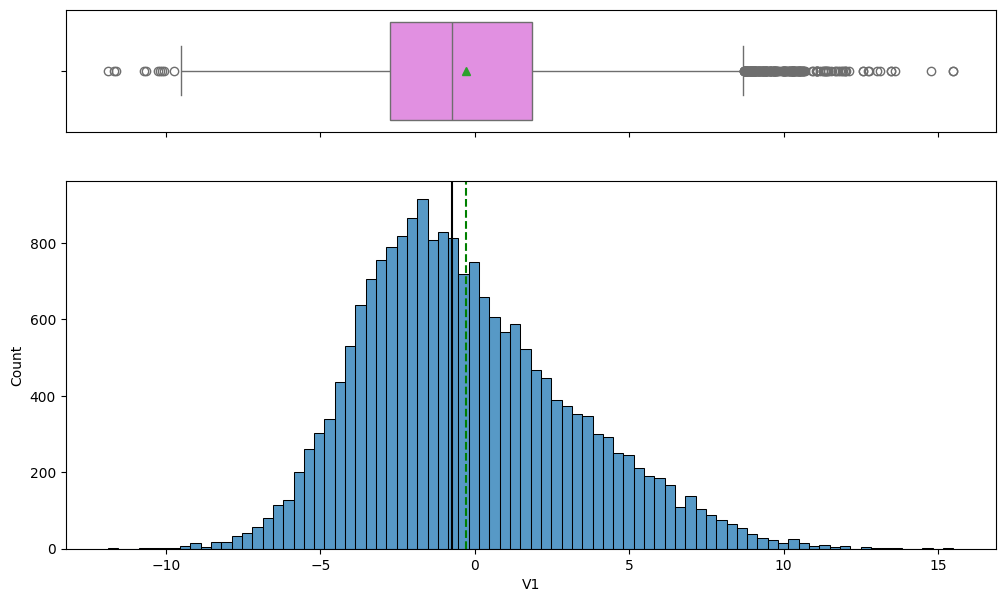

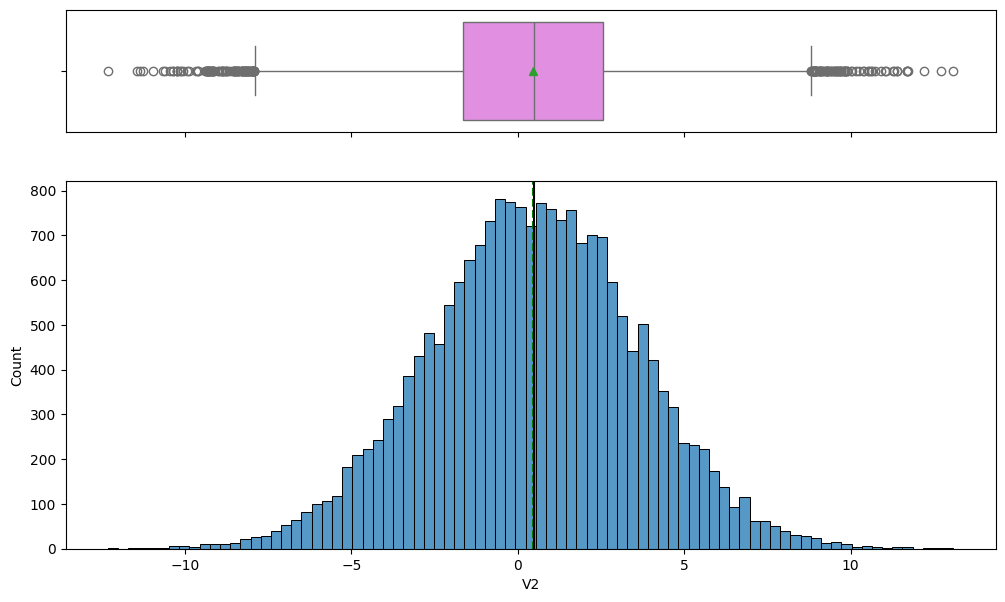

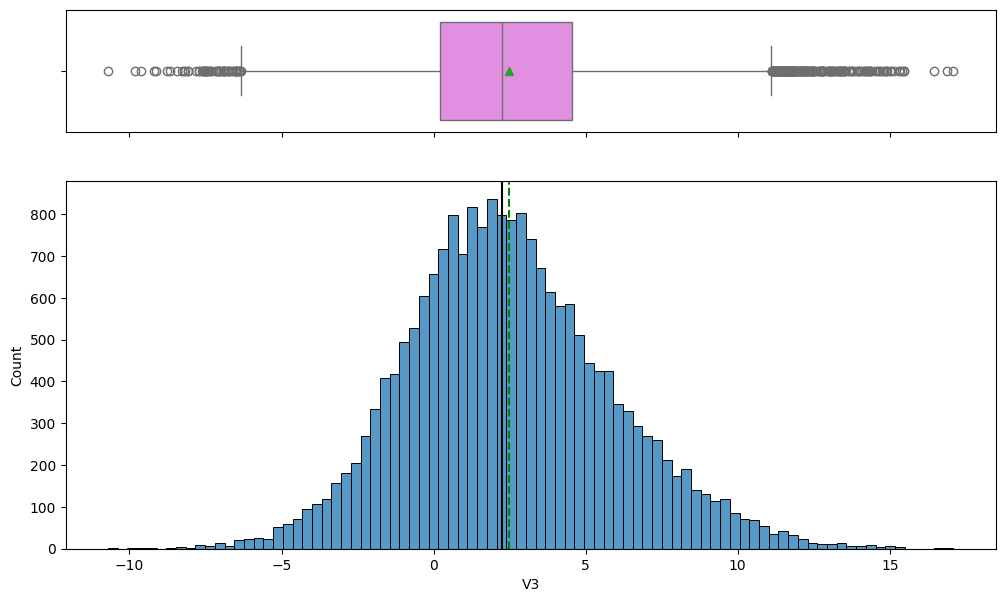

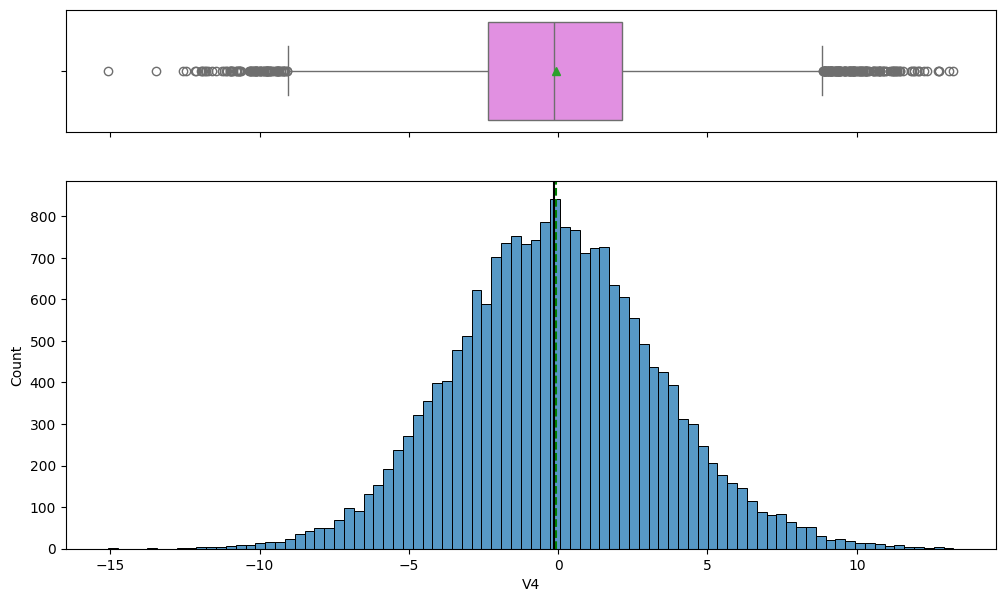

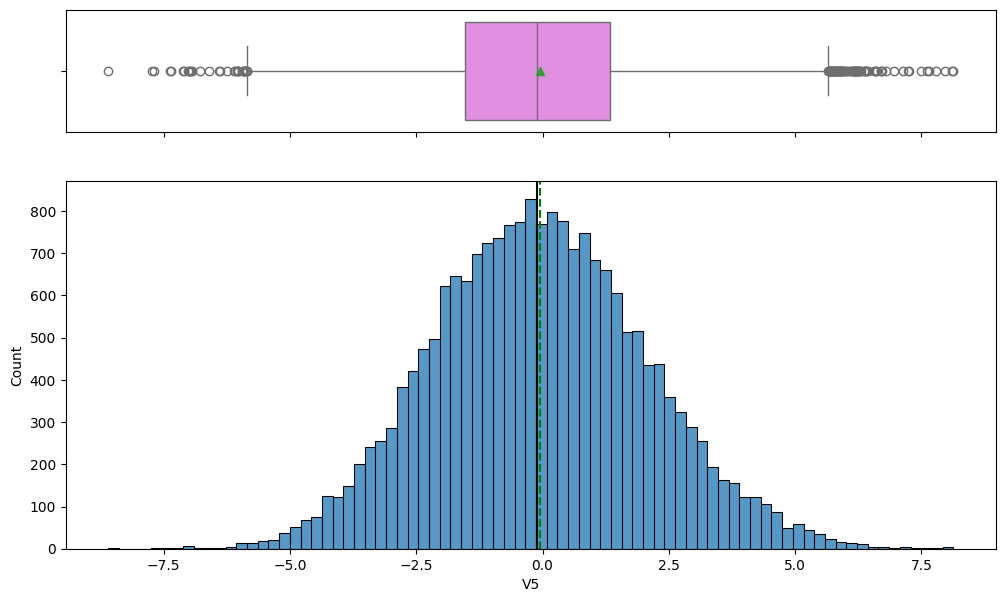

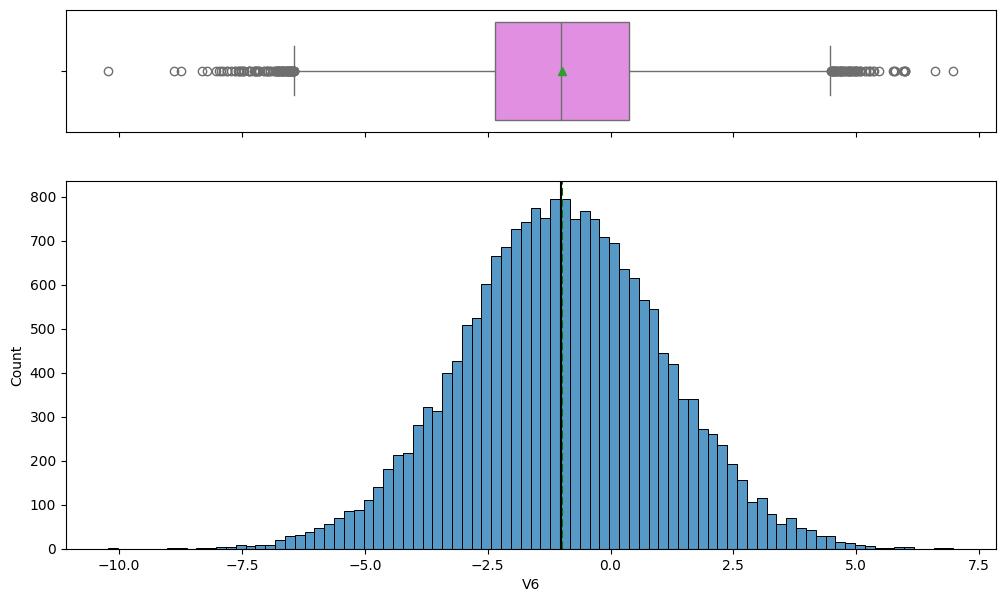

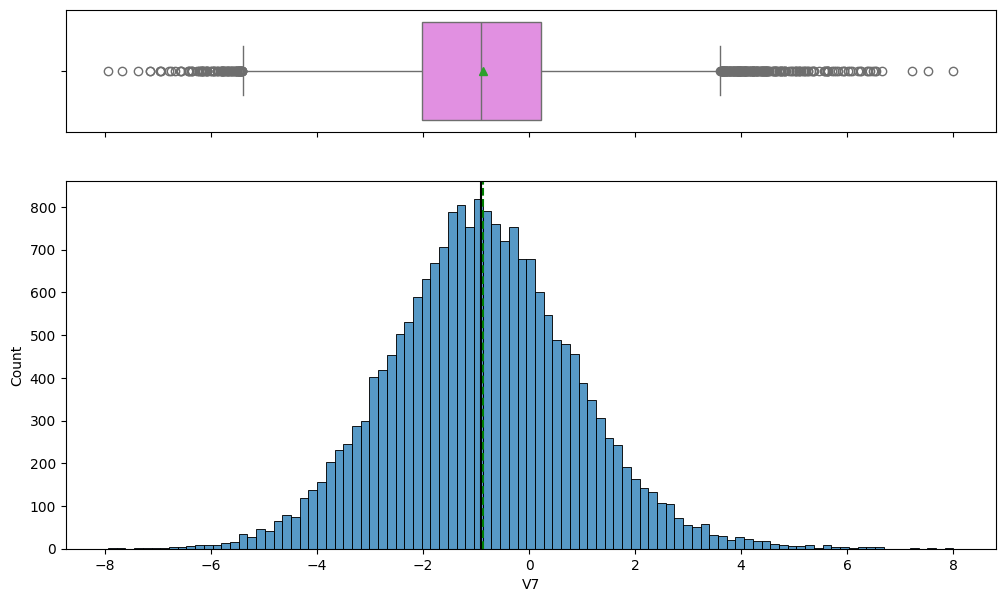

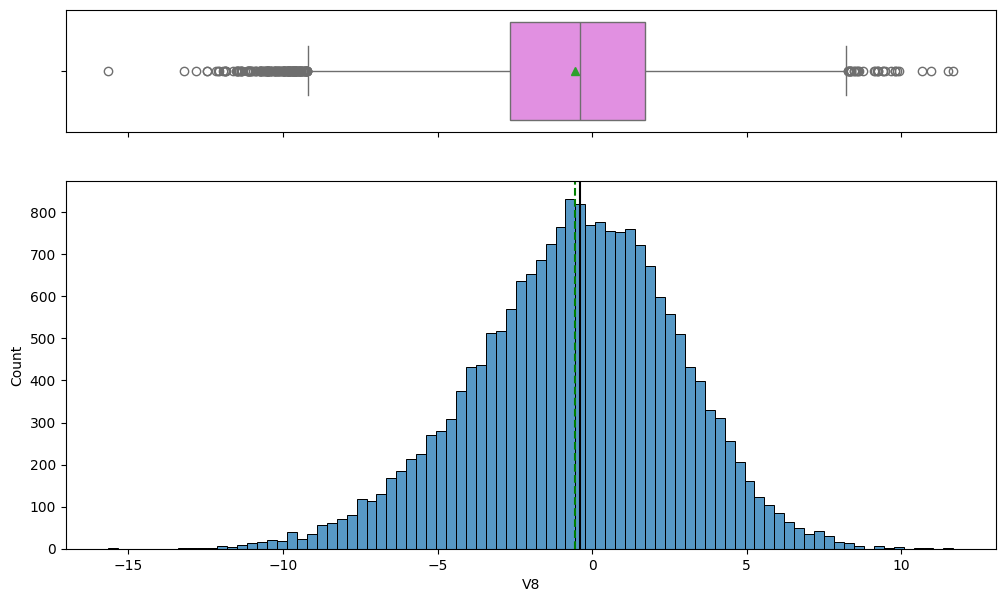

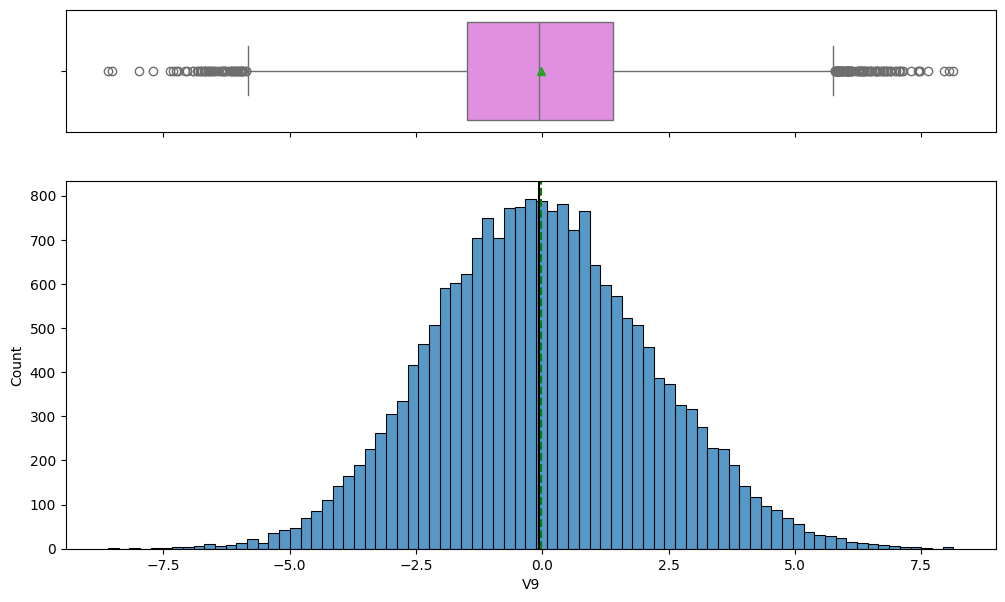

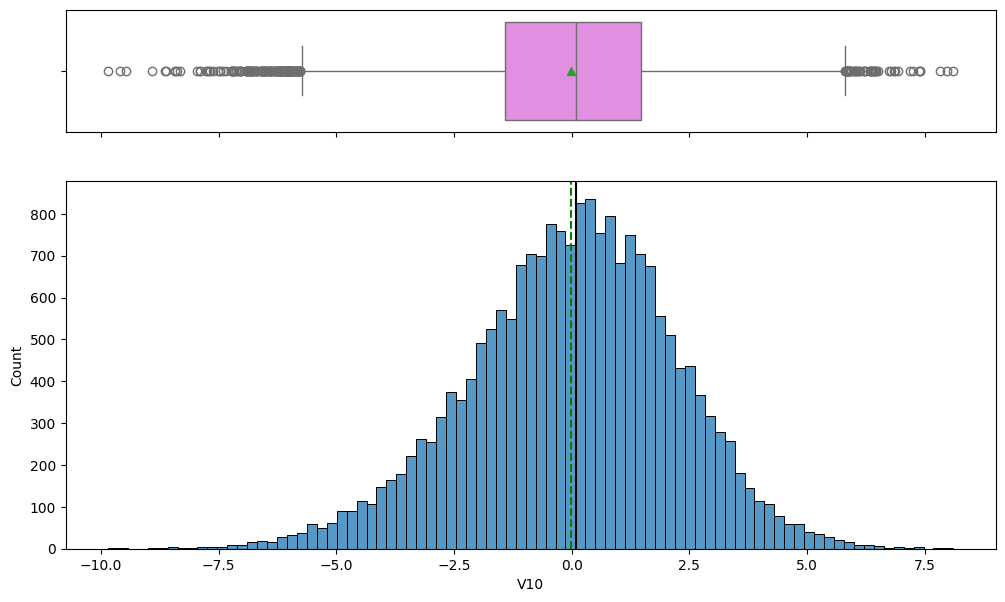

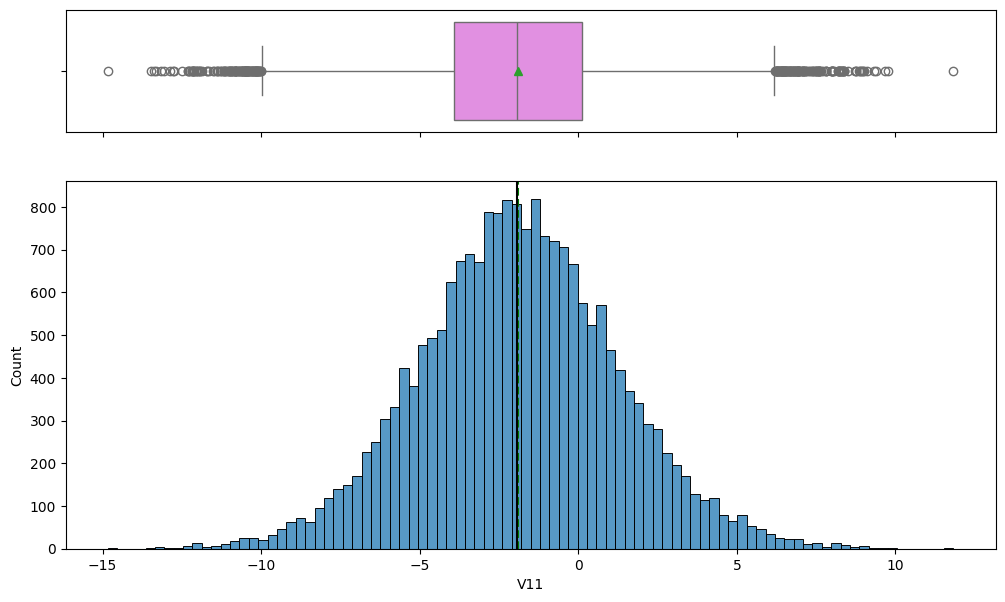

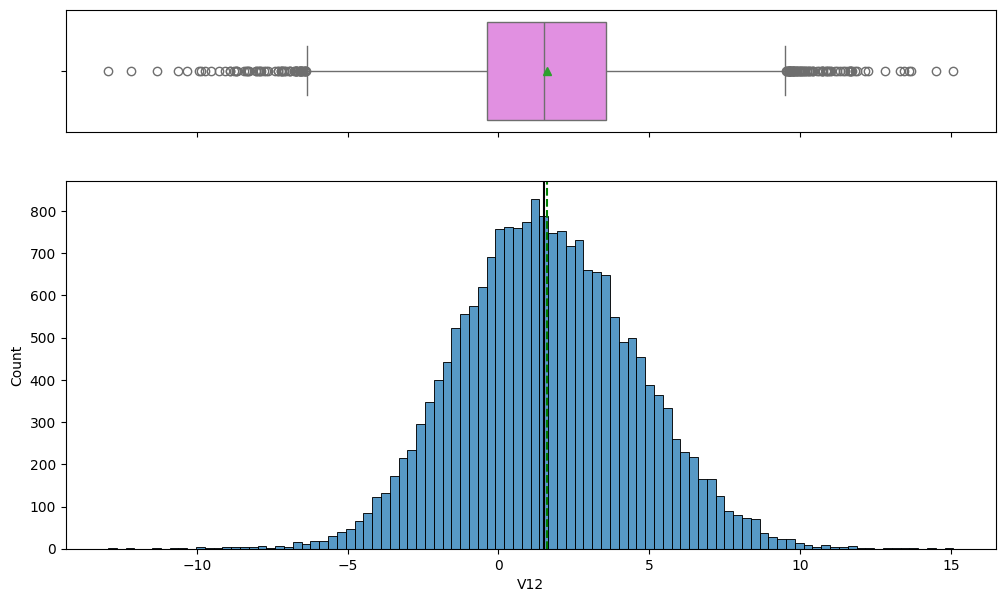

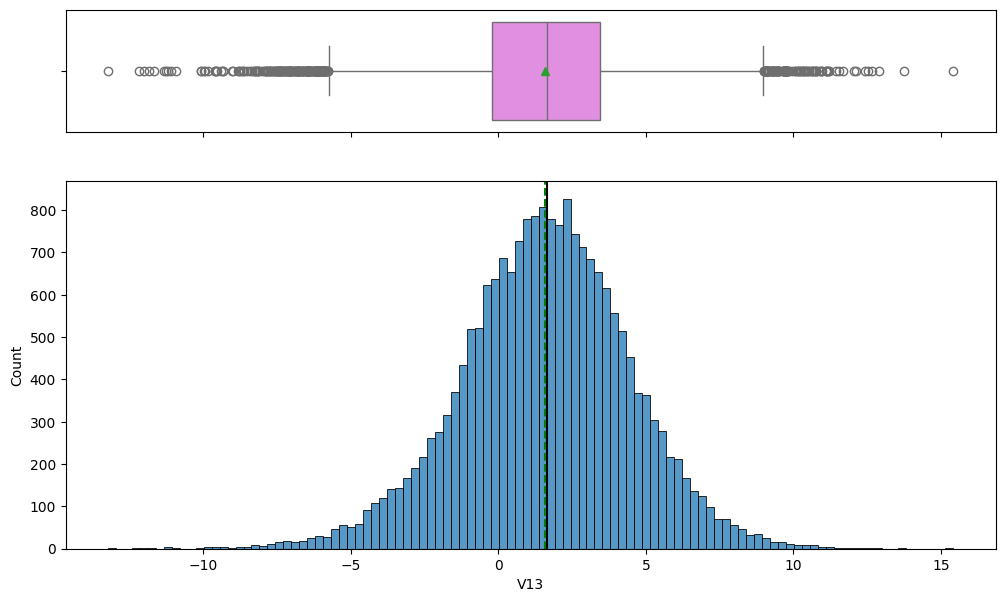

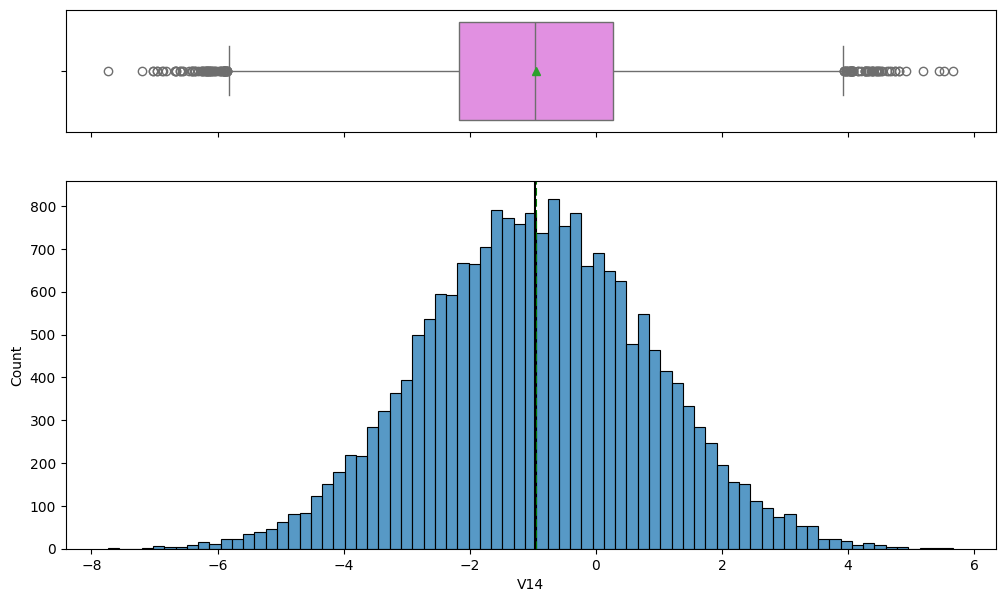

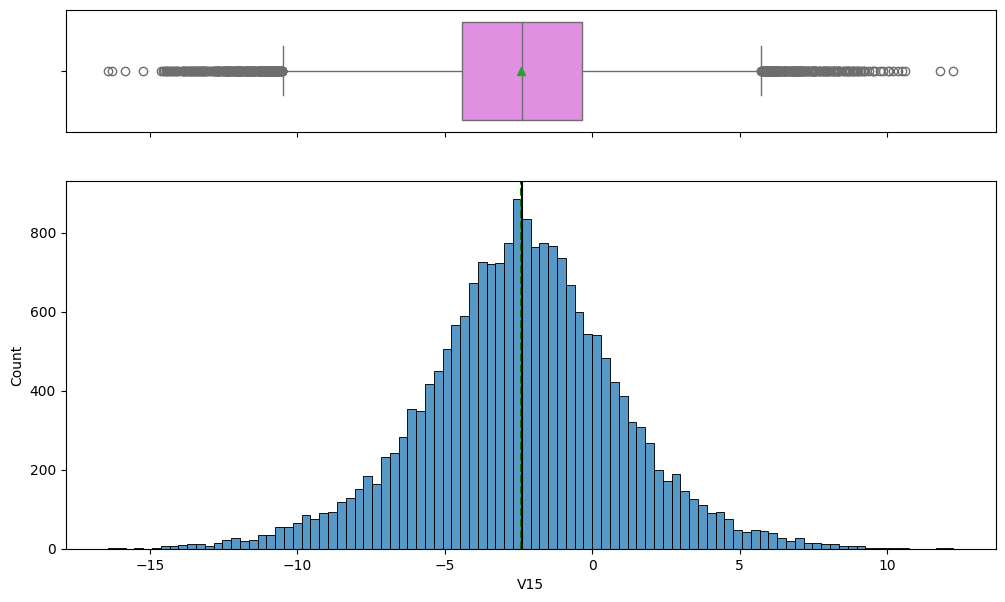

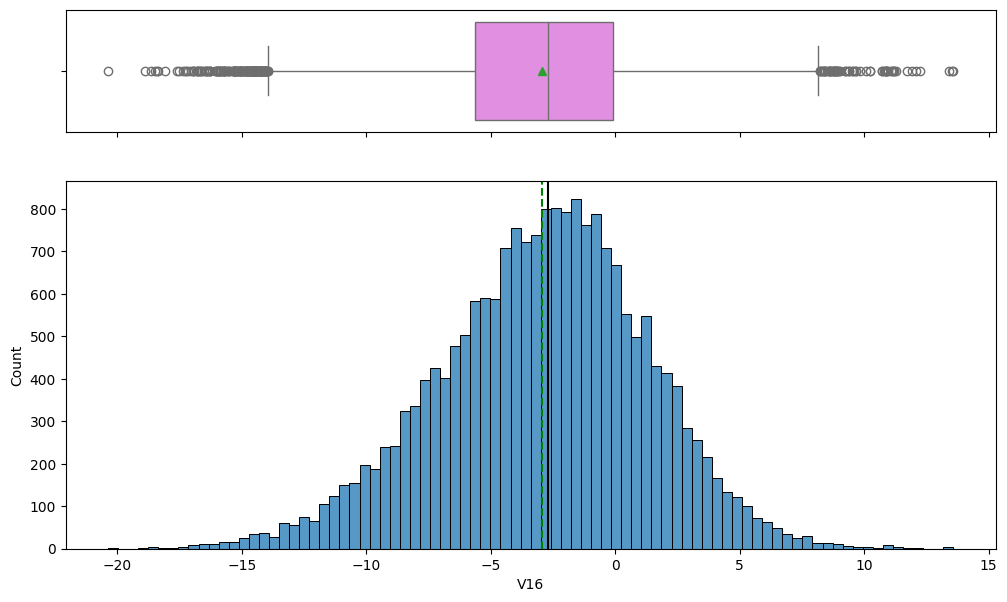

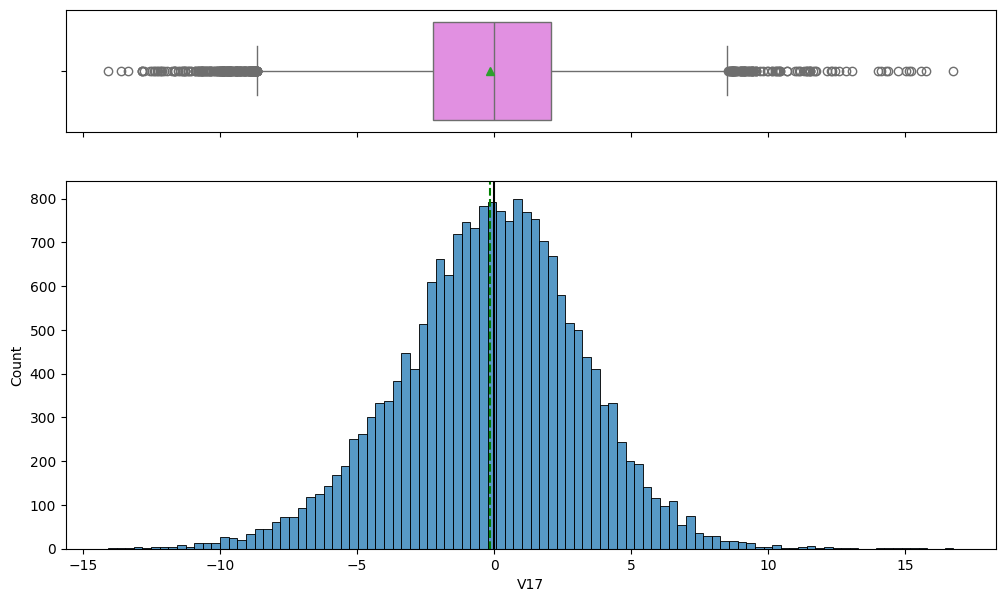

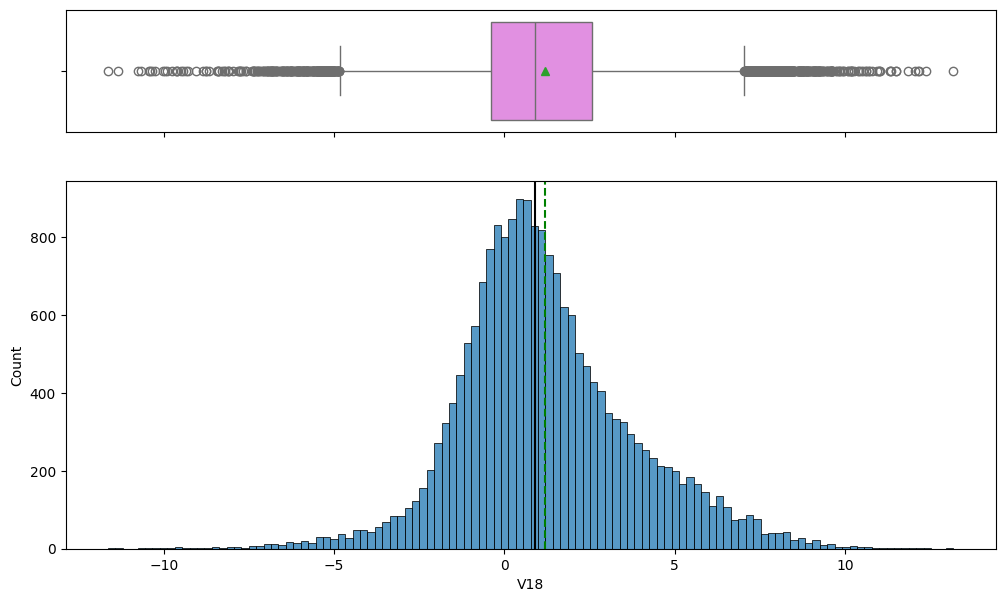

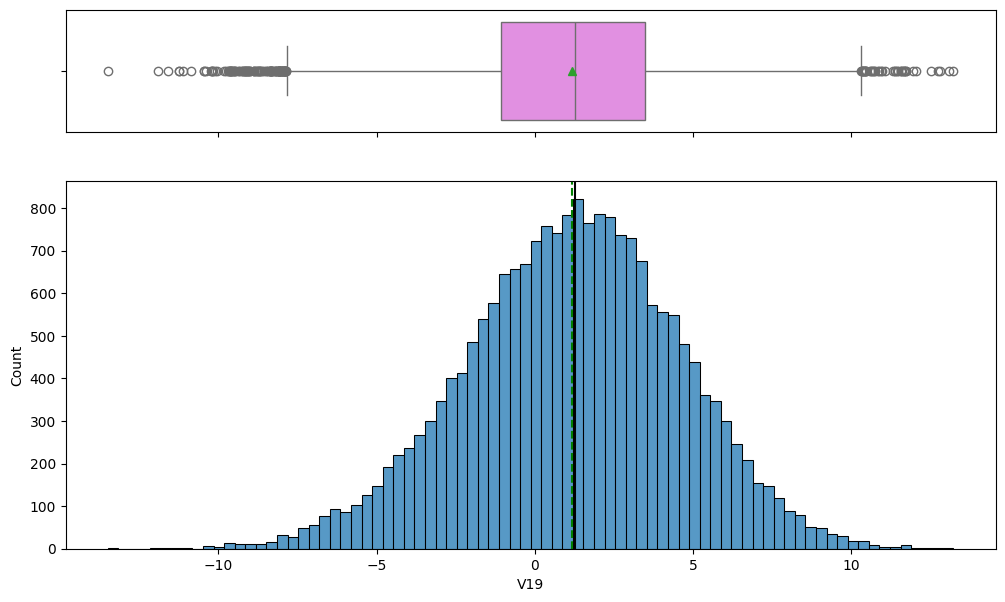

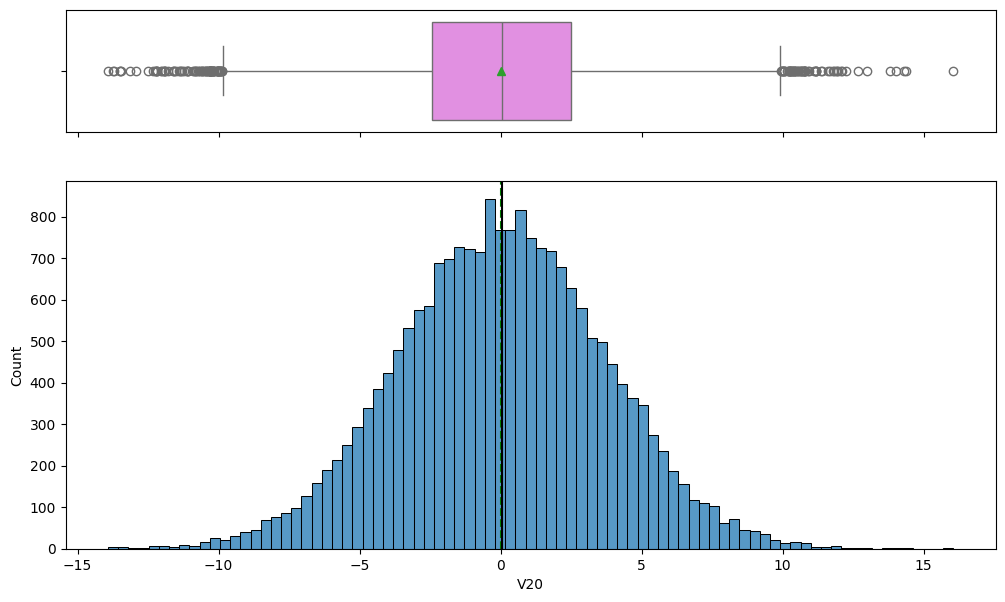

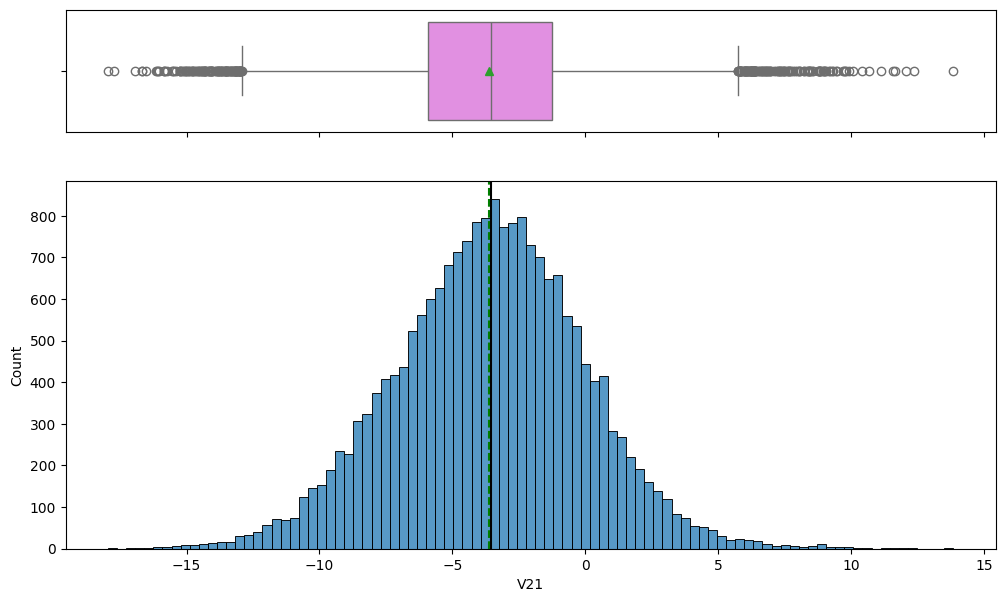

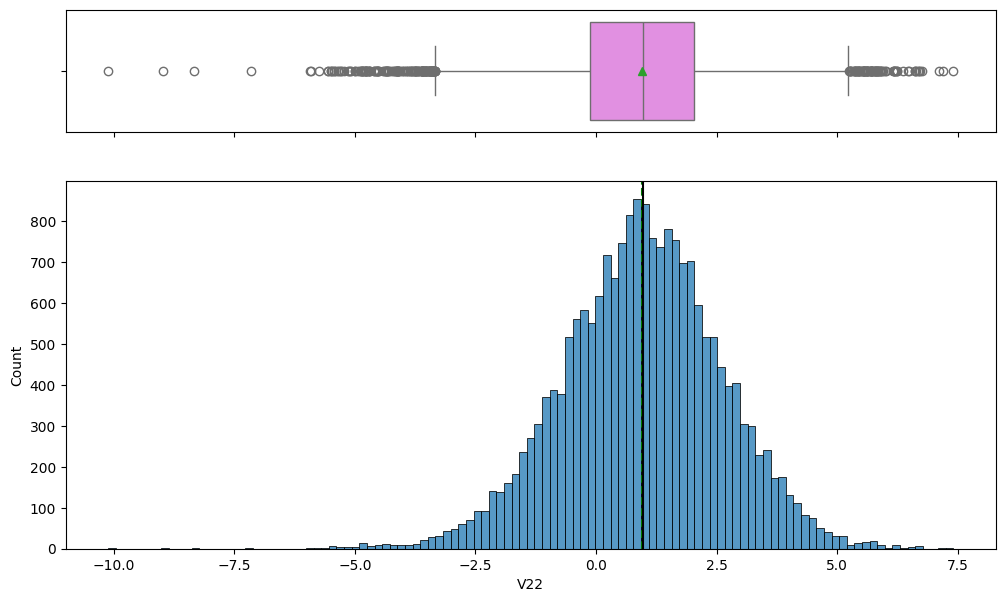

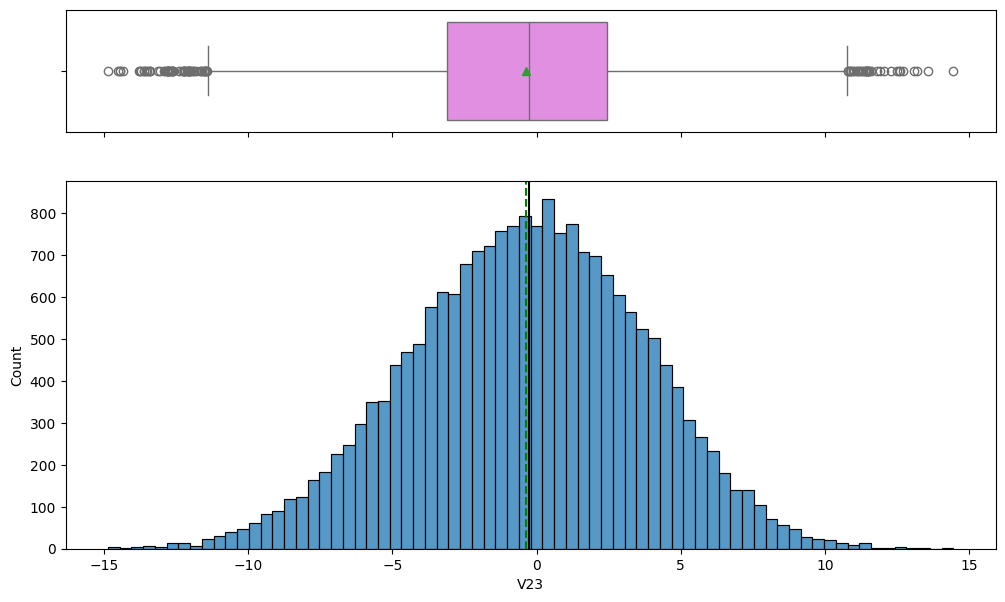

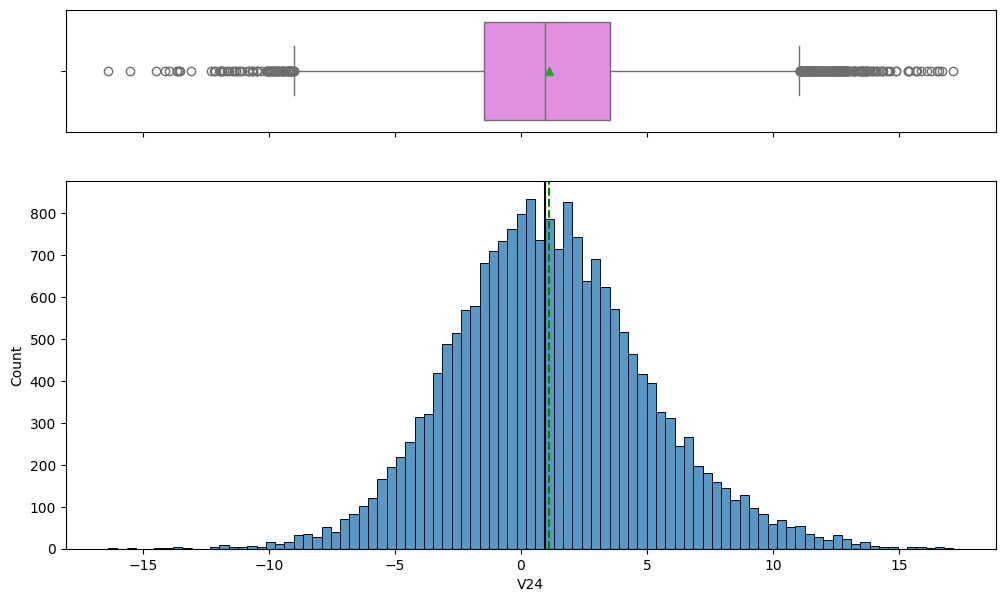

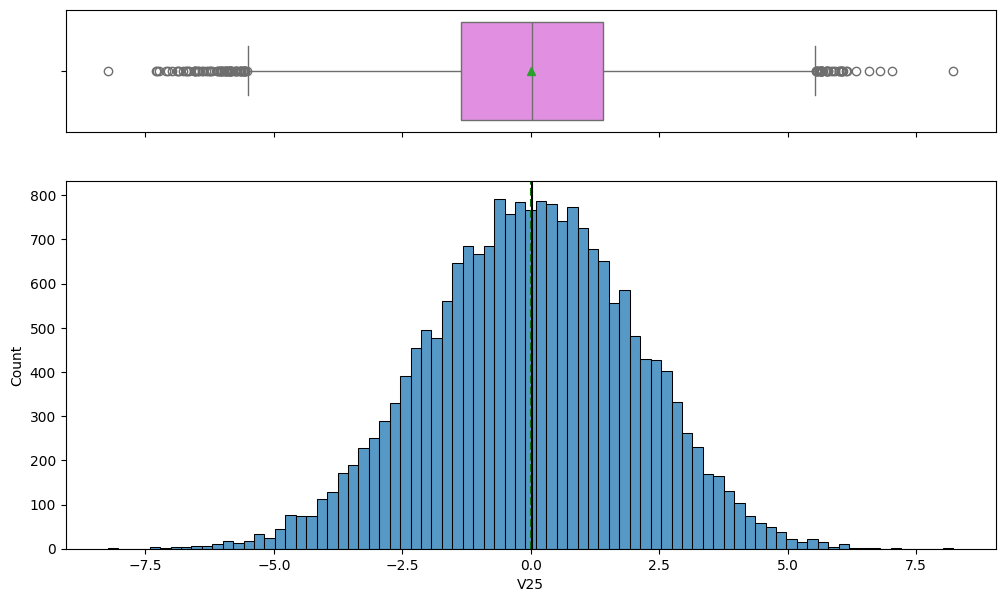

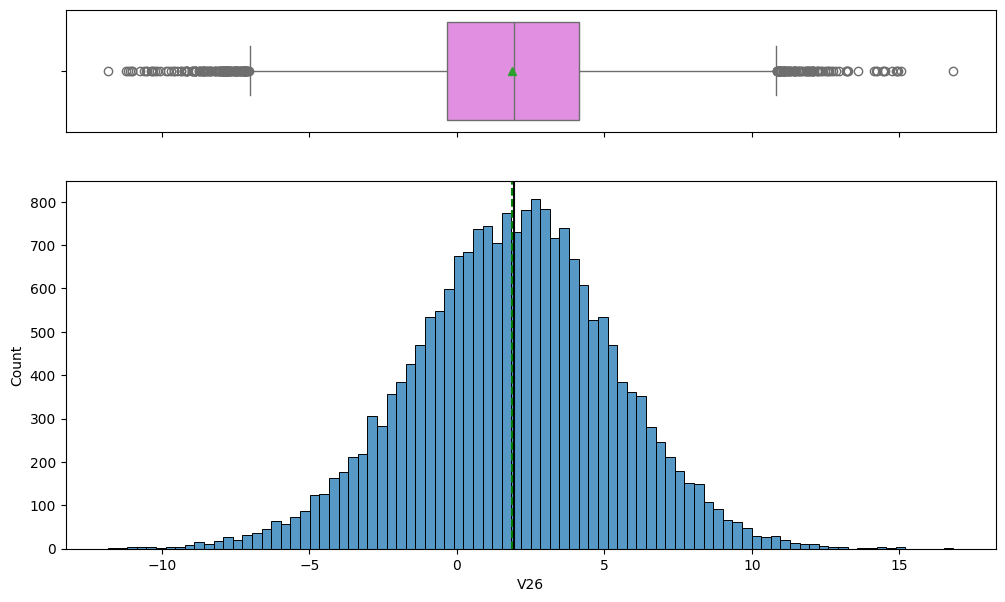

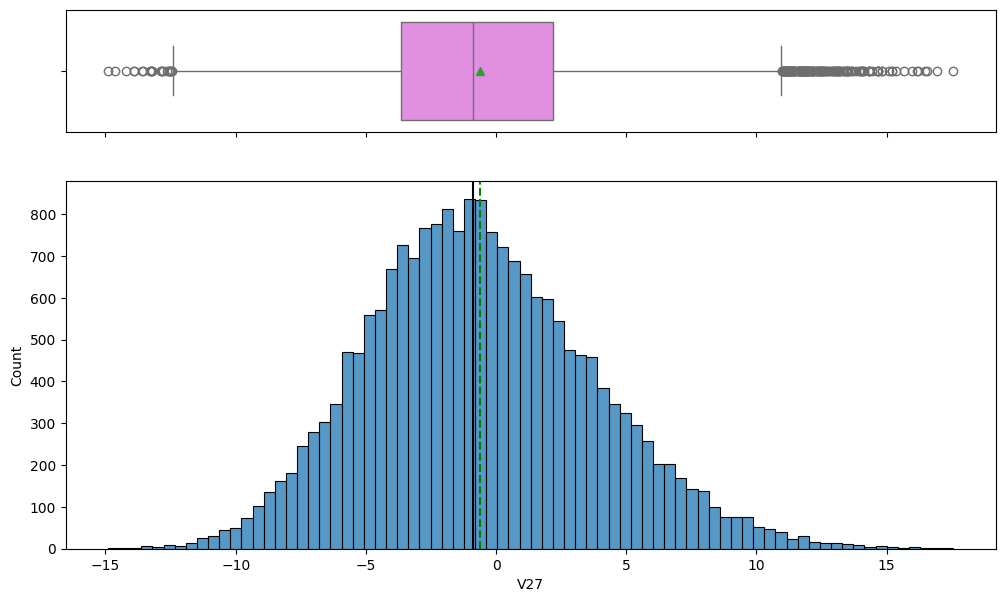

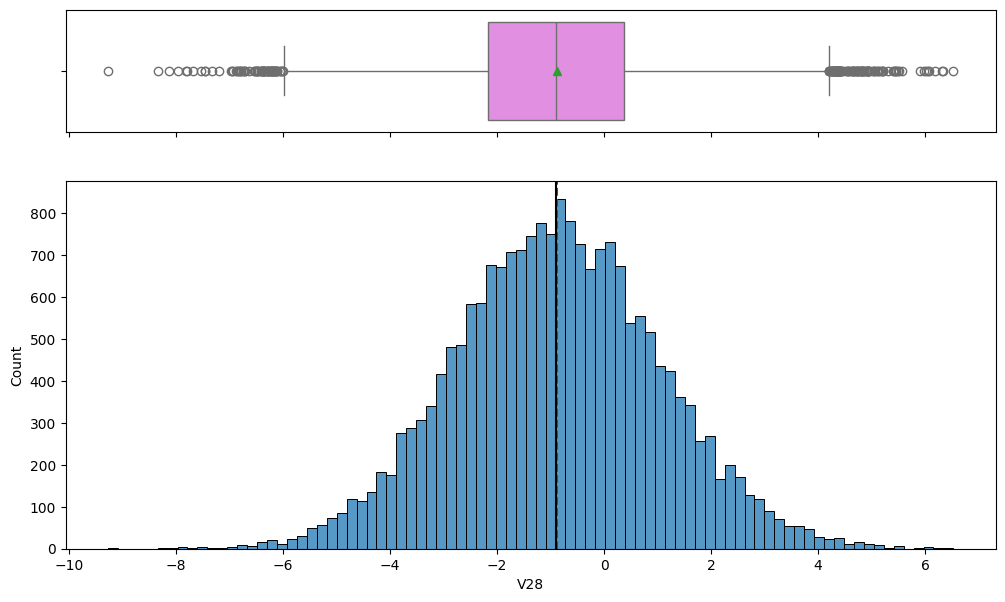

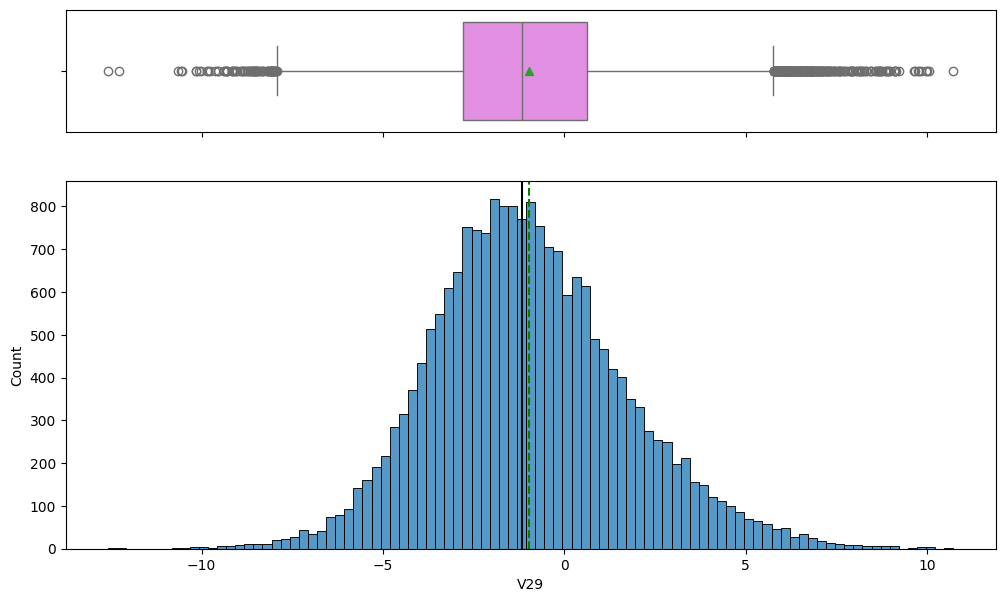

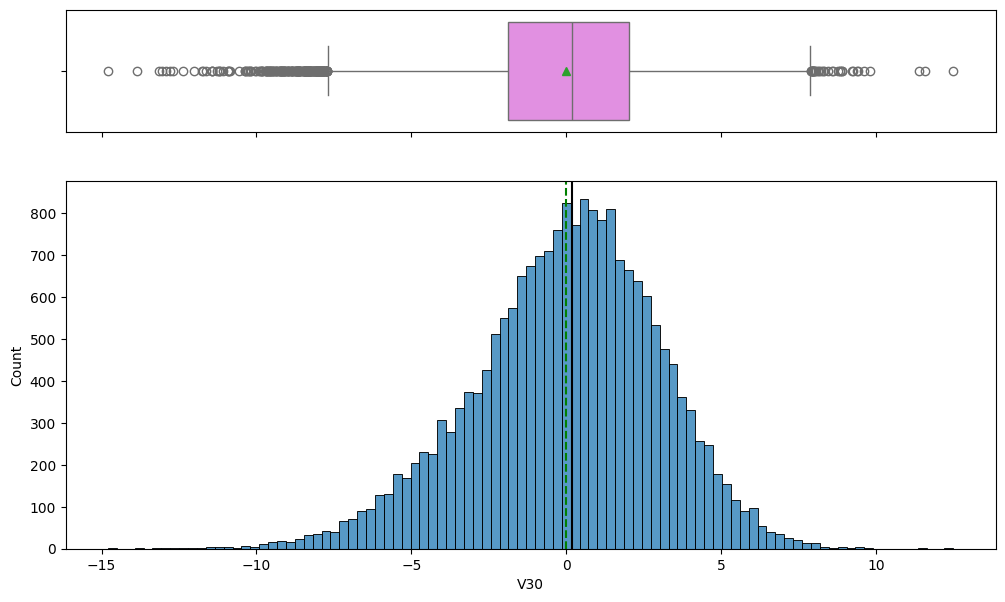

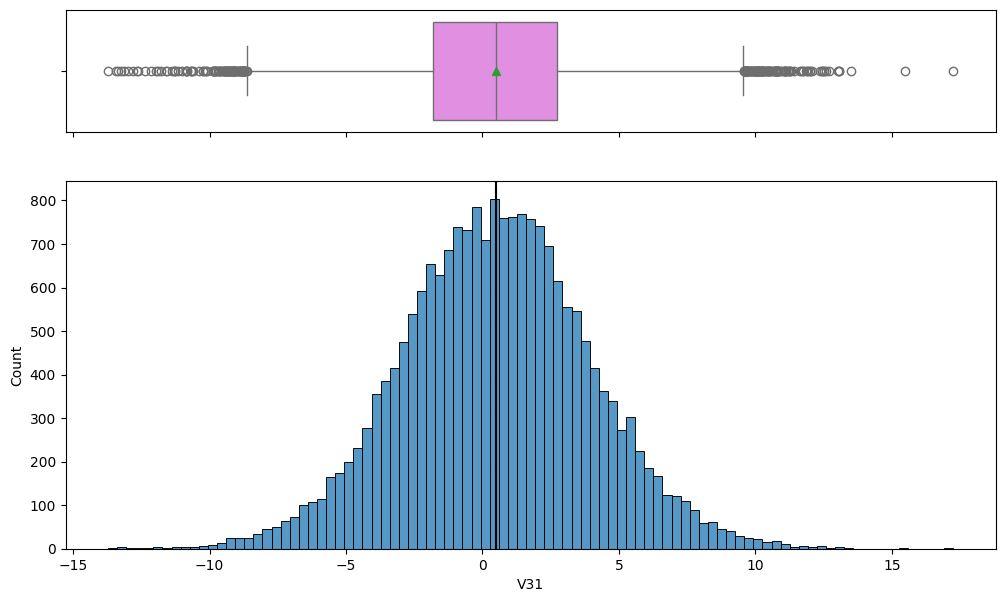

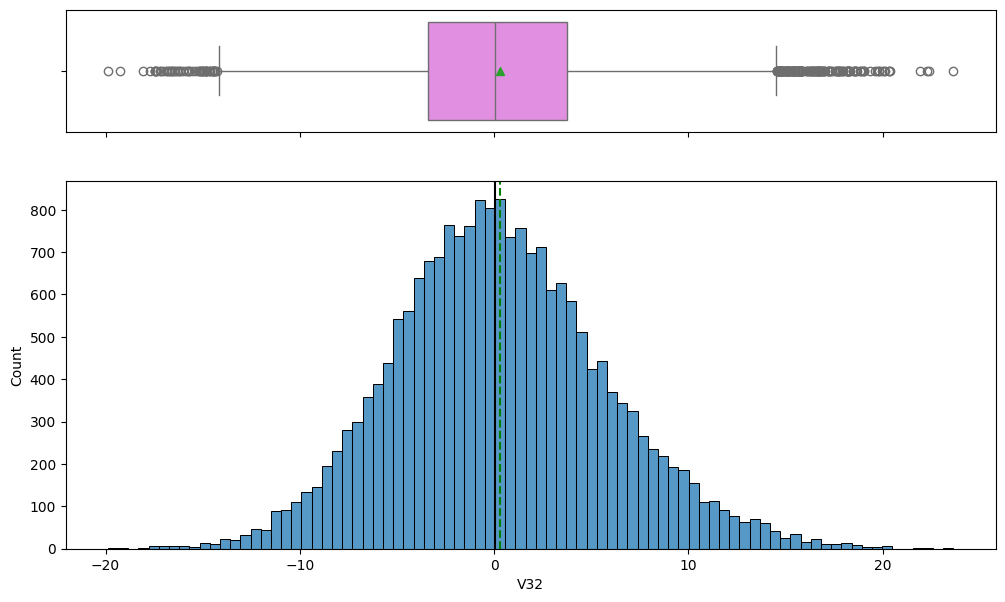

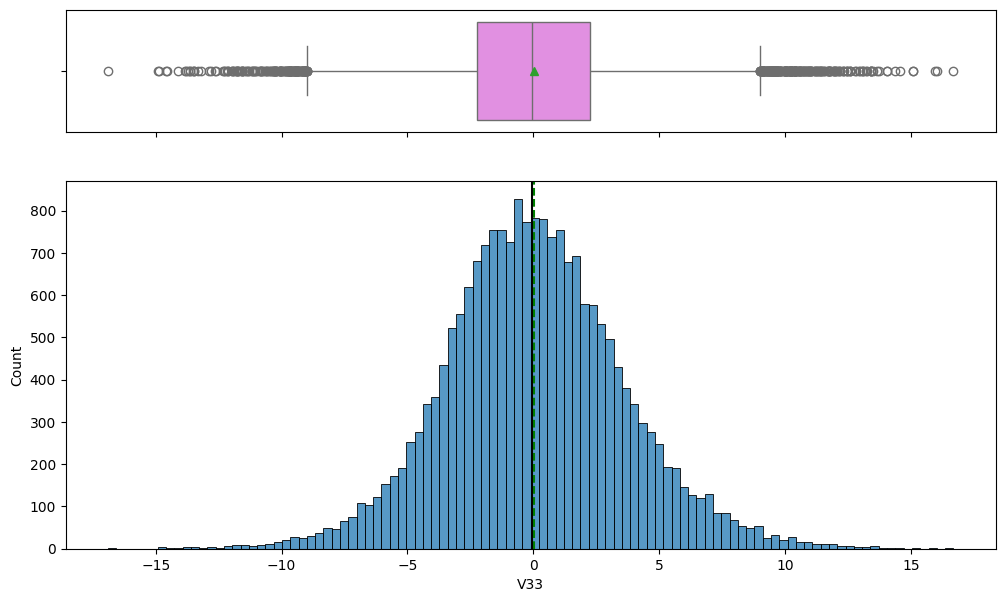

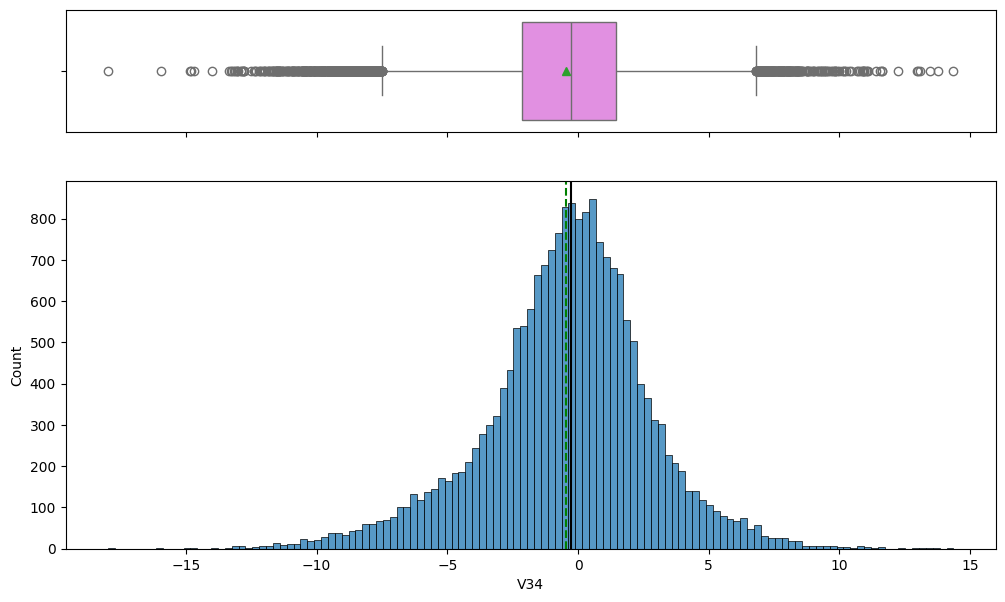

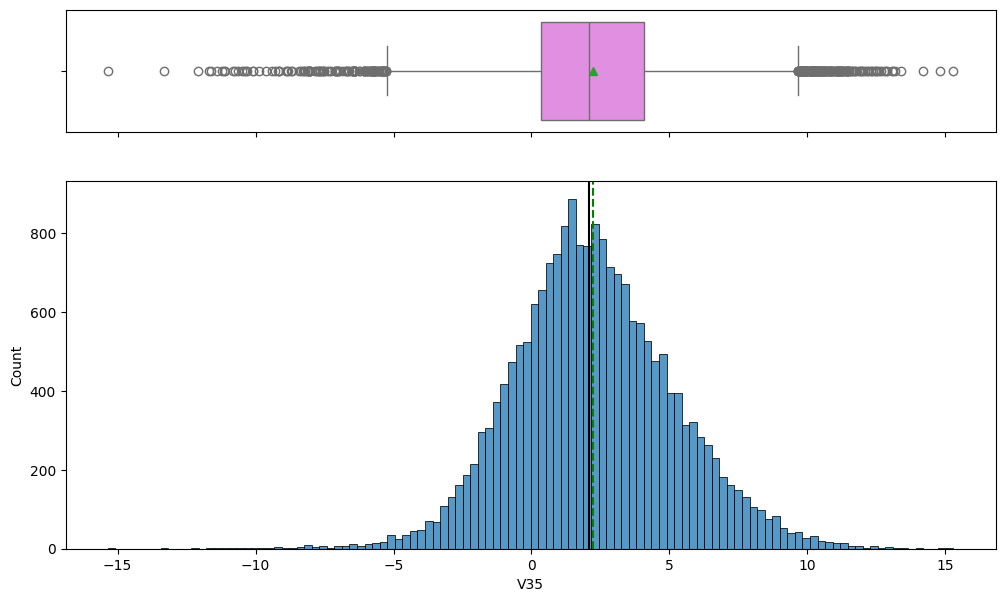

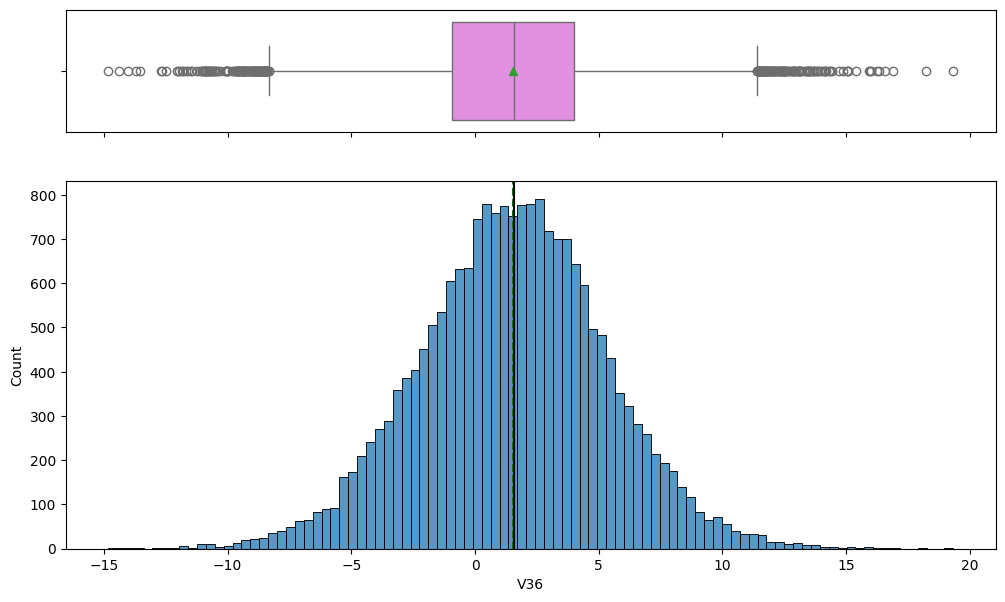

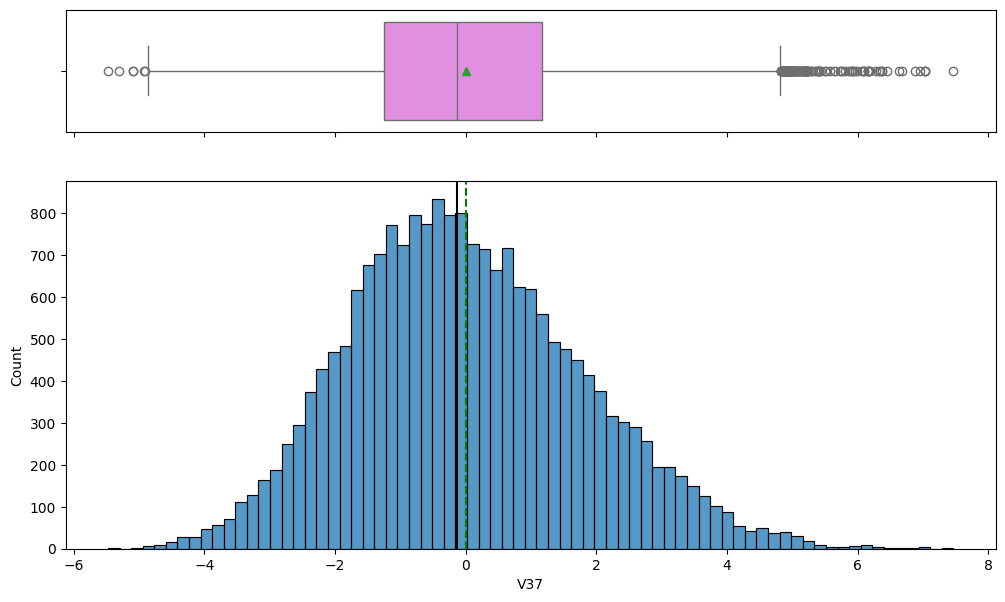

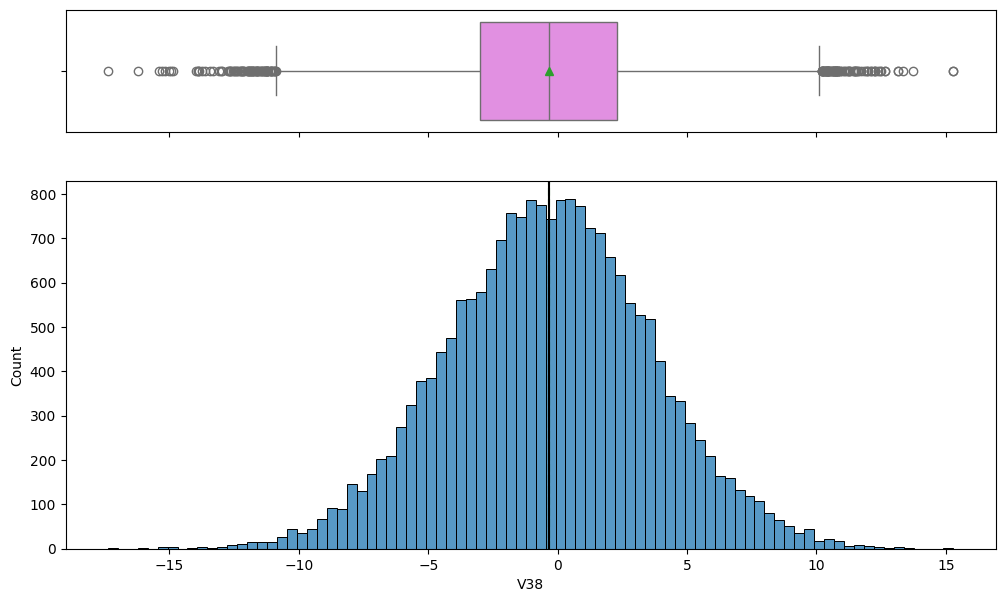

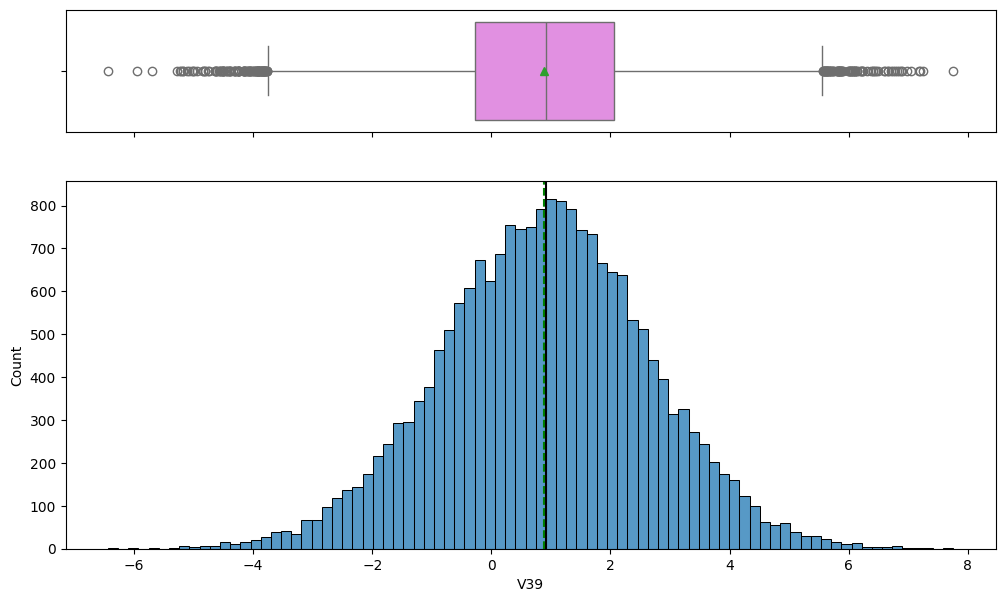

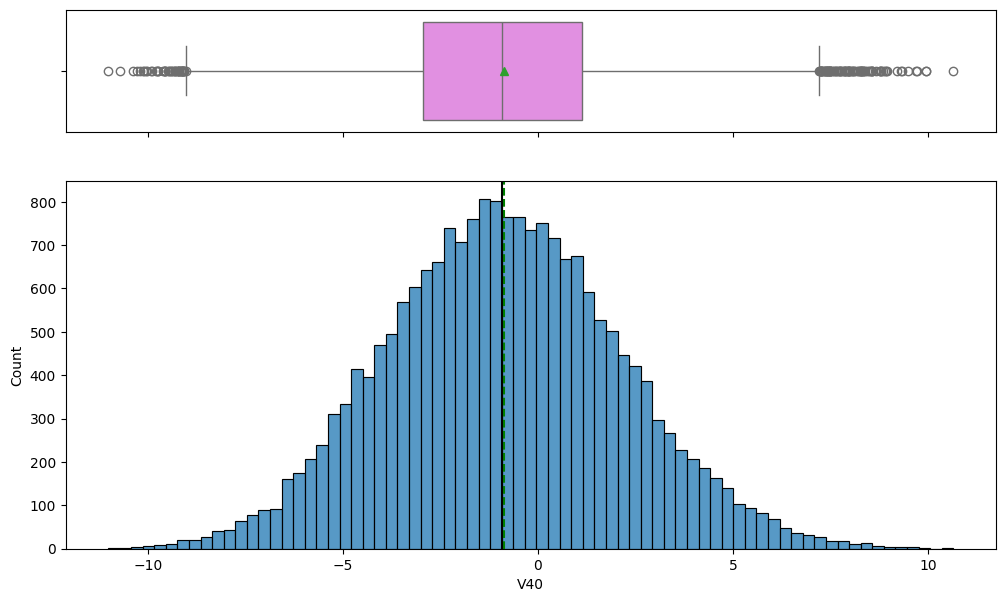

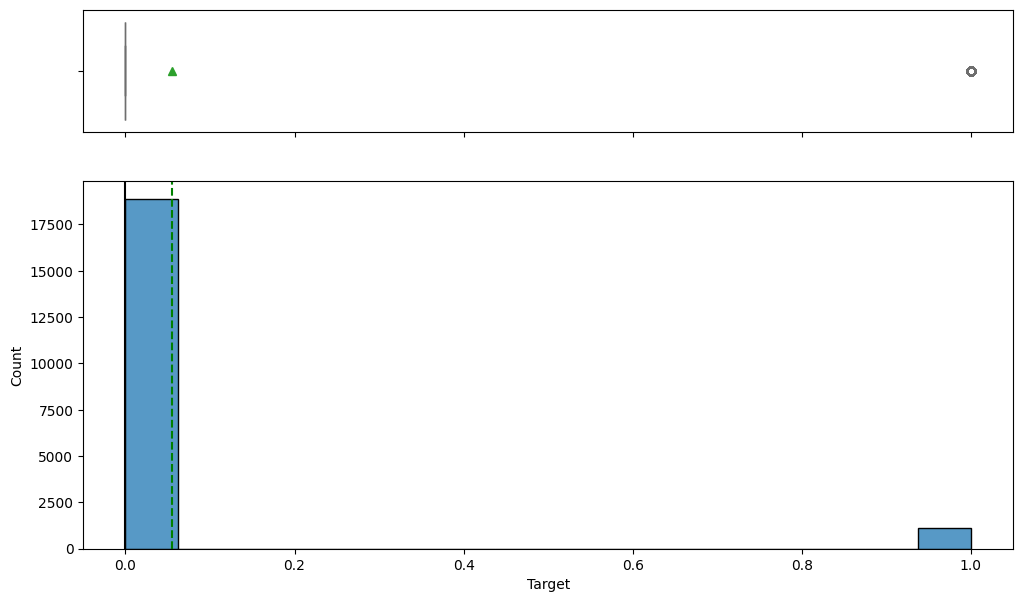

In [ ]:
for feature in data.columns:
    histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None)

* All feature variables have a bell-shaped curve.
* V1, V7, V18, V27, V29, and V37 reflect a relatively more pronounced right skew.
* V8, V10, V16, V22, V30, and V34 reflect a relatively most pronounced left skew.
* All features variables reflect outliers.

### Check target variable value distribution

In [ ]:
# check class distribution in target variable for train:
print("Train data target value counts:  ", data["Target"].value_counts())
print("Percentage of failues in train", data["Target"].value_counts()[1] / data.shape[0] * 100)

# check class distribution in target variable for test:
print("\nTest data target value counts:  ", data_test["Target"].value_counts())
print("Percentage of failues in test", data_test["Target"].value_counts()[1] / data_test.shape[0] * 100)

Train data target value counts:   Target
0    18890
1     1110
Name: count, dtype: int64
Percentage of failues in train 5.55

Test data target value counts:   Target
0    4718
1     282
Name: count, dtype: int64
Percentage of failues in test 5.64


* In train, 5.55% of the records (1110/20,000) are counted as failures.
* In test, 5.64% of records (282/5000) are counted as failures.

###Correlation matrix

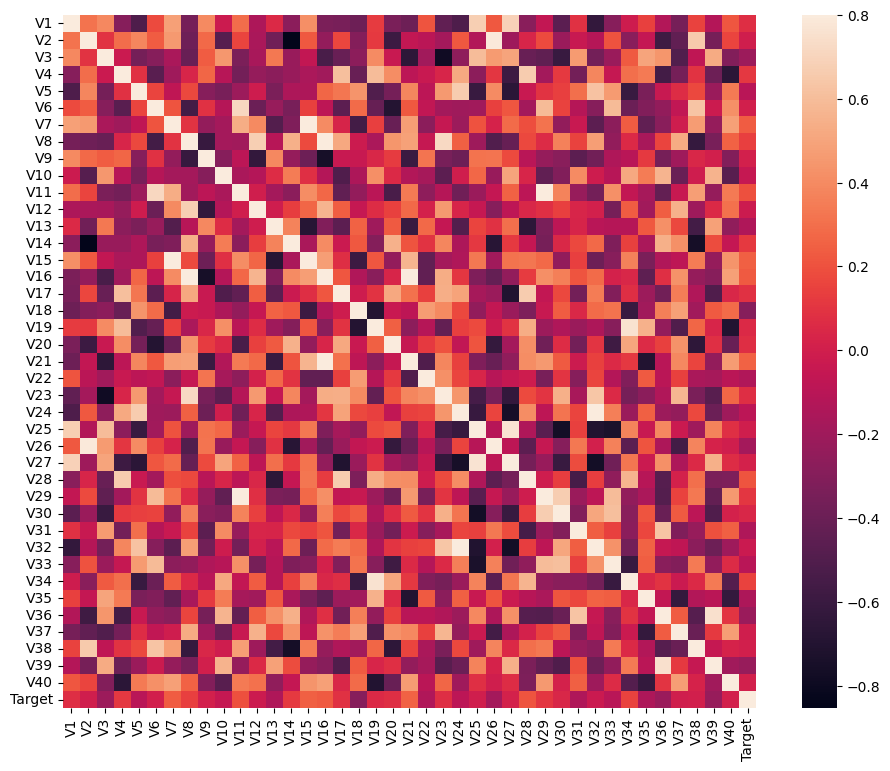

In [ ]:
# Correlation matrix:
corrmat = data.corr()
f, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corrmat, vmax=.8, square=True);

In [ ]:
# List top 5 variables with positive correlation with target:
print("Top 5 variables with positive correlation with target:")
corrmat["Target"].sort_values(ascending=False).head(6)

Top 5 variables with positive correlation with target:


,Target
Target,1.000
V21,0.256
V15,0.249
V7,0.237
V16,0.231
V28,0.207


* No high positive correlations with the target.
* The highest coefficient value is for V21 at .256.

In [ ]:
# List top 5 variables with strongest negative correlation with target:
print("Top 5 variables with negative correlation with target:")
corrmat["Target"].sort_values(ascending=True).head(5)

Top 5 variables with negative correlation with target:


,Target
V18,-0.293
V39,-0.227
V36,-0.216
V3,-0.214
V26,-0.180


* No high negative correlation with the target.
* The largest coefficient value is for V18 at -.293.

In [ ]:
# List top 5 predictor pairs with high absolute correlation:
print("Predictive pairs with highest absolute correlation (positive/negative) are:")
corr_matrix = data.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(np.bool_))
upper.stack().sort_values(ascending=False).head(5)

Predictive pairs with highest absolute correlation (positive/negative) are:


,,0
V7,V15,0.868
V2,V14,0.854
V16,V21,0.837
V24,V32,0.825
V11,V29,0.811


* The top five variables with the strongest positive correlation with the target are V21, V15, V7, V11, V16, and V28.

* The top 5 variables with the strongest negative correlation with the target are V18, V39, V36, V3, and V26.

* The strongest correlation between any two feature variables:
  *  V7	and V15
  *  V16 and V21
  *  V24 and V32
  *  V11 and V29
  *  V8	and V16

## Data Pre-processing
* Divide train data into X and y
* Split train into train and validation
* Divide test data into X_test and y_test

In [ ]:
# Dividing train data into X and y
X = data.drop(["Target"], axis=1)
y = data["Target"]

In [ ]:
# Split the train dataset into train and validation set in the ratio 75:25:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.25, random_state=1, stratify=y)


In [ ]:
# Check the number of rows and columns in the X_train data:
print("The number of rows and columns in X_train are:\n", X_train.shape)

# Check the number of rows and columns in the X_val data:
print("The number of rows and columns in X_val are:\n",X_val.shape)

The number of rows and columns in X_train are:
 (15000, 40)
The number of rows and columns in X_val are:
 (5000, 40)


In [ ]:
# Divide test data into X_test and y_test:
X_test = data_test.drop(["Target"], axis=1)
y_test = data_test["Target"]

In [ ]:
# Check the number of rows and columns in X_test:
print("The number of rows and columns in X_test are:\n", X_test.shape)

The number of rows and columns in X_test are:
 (5000, 40)


* Train now has 15,000 records.
* Validation and test each of 5000 records.

## Missing value imputation




In [ ]:
# Create an instace of the imputer to be used:
imputer = SimpleImputer(strategy="median")

In [ ]:
# Fit and transform the train data
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)

# Transform the validation data:
# Impute missing values in X_val without data leakage:
X_val = pd.DataFrame(imputer.transform(X_val), columns=X_train.columns)

# Transform the test data:
# Impute missing values in X_test without data leakage:
X_test = pd.DataFrame(imputer.transform(X_test), columns=X_train.columns)

In [ ]:
# Check that no column has missing values in train, validation, or test sets:
print(X_train.isna().sum())
print("-" * 30)
print(X_val.isna().sum())
print("-" * 30)
print(X_test.isna().sum())

V1     0
V2     0
V3     0
V4     0
V5     0
V6     0
V7     0
V8     0
V9     0
V10    0
V11    0
V12    0
V13    0
V14    0
V15    0
V16    0
V17    0
V18    0
V19    0
V20    0
V21    0
V22    0
V23    0
V24    0
V25    0
V26    0
V27    0
V28    0
V29    0
V30    0
V31    0
V32    0
V33    0
V34    0
V35    0
V36    0
V37    0
V38    0
V39    0
V40    0
dtype: int64
------------------------------
V1     0
V2     0
V3     0
V4     0
V5     0
V6     0
V7     0
V8     0
V9     0
V10    0
V11    0
V12    0
V13    0
V14    0
V15    0
V16    0
V17    0
V18    0
V19    0
V20    0
V21    0
V22    0
V23    0
V24    0
V25    0
V26    0
V27    0
V28    0
V29    0
V30    0
V31    0
V32    0
V33    0
V34    0
V35    0
V36    0
V37    0
V38    0
V39    0
V40    0
dtype: int64
------------------------------
V1     0
V2     0
V3     0
V4     0
V5     0
V6     0
V7     0
V8     0
V9     0
V10    0
V11    0
V12    0
V13    0
V14    0
V15    0
V16    0
V17    0
V18    0
V19    0
V20    0
V21    0
V22

* Using median values from the train set, imputed missing values in train, validation, and test.
* No missing values remain in any of the three data sets.

## Model Building

### Model evaluation criterion

The nature of predictions made by the classification model will translate as follows:

- True positives (TP) are failures correctly predicted by the model.
- False negatives (FN) are real failures in a generator where there is no detection by model.
- False positives (FP) are failure detections in a generator where there is no failure.

**Which metric to optimize?**

* We need to choose the metric which will ensure that the maximum number of generator failures are predicted correctly by the model.
* We would want Recall to be maximized as greater the Recall, the higher the chances of minimizing false negatives.
* We want to minimize false negatives because if a model predicts that a machine will have no failure when there will be a failure, it will increase the maintenance cost.

### Define functions to output performance metrics

In [ ]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn
def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "Accuracy": acc,
            "Recall": recall,
            "Precision": precision,
            "F1": f1

        },
        index=[0],
    )

    return df_perf

### Defining scorer to be used for cross-validation and hyperparameter tuning

- We want to reduce false negatives and will try to maximize "Recall".
- To maximize Recall, we can use Recall as a **scorer** in cross-validation and hyperparameter tuning.

In [ ]:
# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.recall_score)

### Model Building with original data

In [ ]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Logistic regression", LogisticRegression(random_state=1)))
models.append(("Bagging", BaggingClassifier(random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1)))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("Xgboost", XGBClassifier(random_state=1, eval_metric="logloss")))
models.append(("dtree", DecisionTreeClassifier(random_state=1)))

results1 = []  # Empty list to store all model's CV scores
names = []  # Empty list to store name of the models


# loop through all models to get the mean cross validated score
print("\n" "Cross-Validation performance on training dataset:" "\n")

for name, model in models:
    kfold = StratifiedKFold(
        n_splits=5, shuffle=True, random_state=1
    )  # Setting number of splits equal to 5
    cv_result = cross_val_score(
        estimator=model, X=X_train, y=y_train, scoring=scorer, cv=kfold
    )
    results1.append(cv_result)
    names.append(name)
    print("{}: {}".format(name, cv_result.mean()))

print("\n" "Validation Performance:" "\n")

for name, model in models:
    model.fit(X_train, y_train)
    scores = recall_score(y_val, model.predict(X_val))
    print("{}: {}".format(name, scores))


Cross-Validation performance on training dataset:

Logistic regression: 0.4927566553639709
Bagging: 0.7210807301060529
Random forest: 0.7235192266070268
GBM: 0.7066661857008874
Adaboost: 0.6309140754635308
Xgboost: 0.8100497799581561
dtree: 0.6982829521679532

Validation Performance:

Logistic regression: 0.4856115107913669
Bagging: 0.7302158273381295
Random forest: 0.7266187050359713
GBM: 0.7230215827338129
Adaboost: 0.6762589928057554
Xgboost: 0.8309352517985612
dtree: 0.7050359712230215


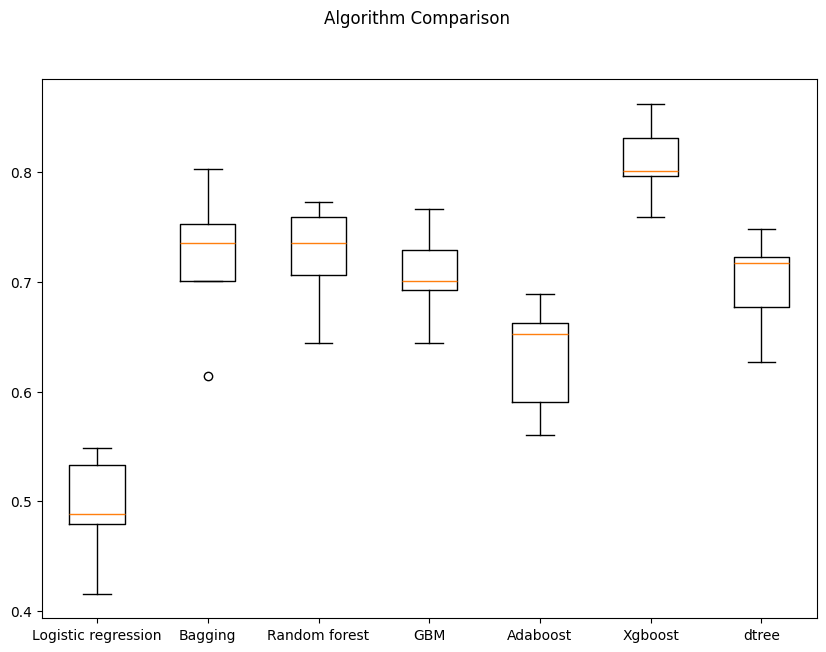

In [ ]:
# Plotting boxplots for CV scores of all models defined above
fig = plt.figure(figsize=(10, 7))

fig.suptitle("Algorithm Comparison")
ax = fig.add_subplot(111)

plt.boxplot(results1)
ax.set_xticklabels(names)

plt.show()

* The mean cross-validation (cv) and recall scores for each model are relatively consistent between train and validation.
* The highest recall score by far is with XGBoost with a predictive cv recall score of 81% in train and recall 83% in validation.
* Second two highest models are Random Forest and Bagging (in validation).
* The lowest recall score by far is Logistic Regression, at 49% in both train and validation.

### Model Building with Oversampled data
 * Use SMOTE add records to minority class to address class imblance.

In [ ]:
print("Before OverSampling, counts of label '1': {}".format(sum(y_train == 1)))
print("Before OverSampling, counts of label '0': {} \n".format(sum(y_train == 0)))

# Synthetic Minority Over Sampling Technique
sm = SMOTE(sampling_strategy=1, k_neighbors=5, random_state=1)
X_train_over, y_train_over = sm.fit_resample(X_train, y_train)

print("After OverSampling, counts of label '1': {}".format(sum(y_train_over == 1)))
print("After OverSampling, counts of label '0': {} \n".format(sum(y_train_over == 0)))

print("After OverSampling, the shape of train_X: {}".format(X_train_over.shape))
print("After OverSampling, the shape of train_y: {} \n".format(y_train_over.shape))

Before OverSampling, counts of label '1': 832
Before OverSampling, counts of label '0': 14168 

After OverSampling, counts of label '1': 14168
After OverSampling, counts of label '0': 14168 

After OverSampling, the shape of train_X: (28336, 40)
After OverSampling, the shape of train_y: (28336,) 



* After applying SMOTE, synthesized records were added to balance out the minority class record count to match the majority class record count (14168).  
* Upon completion, the record count is now 28336 (14168 * 2).

In [ ]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Logistic regression", LogisticRegression(random_state=1)))
models.append(("Bagging", BaggingClassifier(random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1)))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("Xgboost", XGBClassifier(random_state=1, eval_metric="logloss")))
models.append(("dtree", DecisionTreeClassifier(random_state=1)))

results1 = []  # Empty list to store all model's CV scores
names = []  # Empty list to store name of the models


# loop through all models to get the mean cross validated score
print("\n" "Cross-Validation performance on training dataset:" "\n")

for name, model in models:
    kfold = StratifiedKFold(
        n_splits=5, shuffle=True, random_state=1
    )  # Setting number of splits equal to 5
    cv_result = cross_val_score(
        estimator=model, X=X_train_over, y=y_train_over, scoring=scorer, cv=kfold
    )
    results1.append(cv_result)
    names.append(name)
    print("{}: {}".format(name, cv_result.mean()))

print("\n" "Validation Performance:" "\n")

for name, model in models:
    model.fit(X_train_over, y_train_over)
    scores = recall_score(y_val, model.predict(X_val))
    print("{}: {}".format(name, scores))


Cross-Validation performance on training dataset:

Logistic regression: 0.883963699328486
Bagging: 0.9762141471581656
Random forest: 0.9839075260047615
GBM: 0.9256068151319724
Adaboost: 0.8978689011775473
Xgboost: 0.9891305241357218
dtree: 0.9720494245534969

Validation Performance:

Logistic regression: 0.8489208633093526
Bagging: 0.8345323741007195
Random forest: 0.8489208633093526
GBM: 0.8776978417266187
Adaboost: 0.8561151079136691
Xgboost: 0.8669064748201439
dtree: 0.7769784172661871


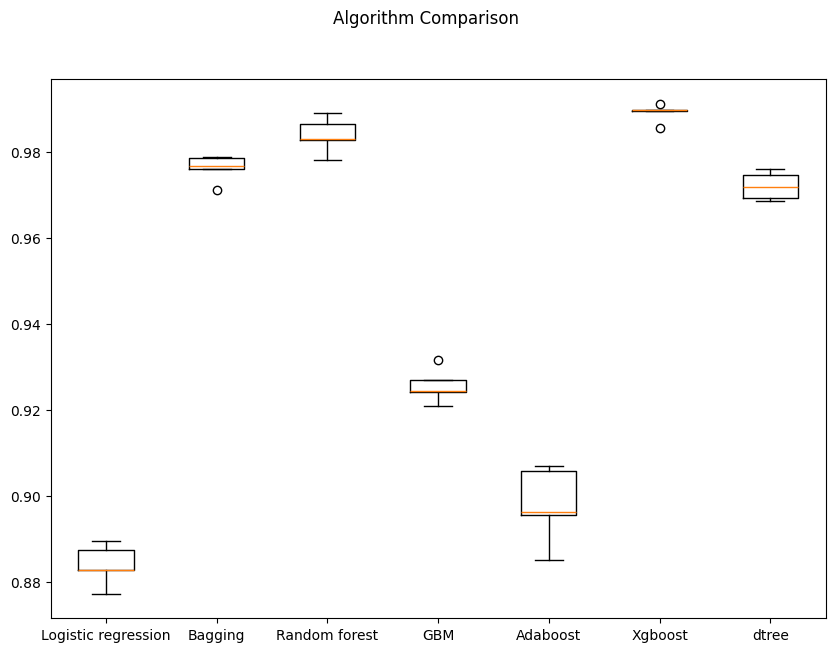

In [ ]:
# Plotting boxplots for CV scores of all models defined above
fig = plt.figure(figsize=(10, 7))

fig.suptitle("Algorithm Comparison")
ax = fig.add_subplot(111)

plt.boxplot(results1)
ax.set_xticklabels(names)

plt.show()

* Recall performance shifted significantly logistic regression post-over-sampling, moving up from 49% to 85% in validation, with a cv score of 88% in train.
* More discrepancy exists between the mean recall cv scores in train and validation recall scores, particularly with Bagging, Random Forest, XGBoost, and Decision Tree.
* Although XGBoost maintains the highest cv score in train at 99%, Gradient Boost (GBM) has the highest recall score (88%) in validation post-SMOTE.
* XGBoost recall in validation is still close, at 87% in validation, followed by AdaBoost at 86%.

### Model Building with Undersampled data
* Use Random Undersampler to reduce number of records in the majority class.

In [ ]:
# Random undersampler for under sampling the data
rus = RandomUnderSampler(random_state=1, sampling_strategy=1)
X_train_un, y_train_un = rus.fit_resample(X_train, y_train)

print("Before UnderSampling, counts of label '1': {}".format(sum(y_train == 1)))
print("Before UnderSampling, counts of label '0': {} \n".format(sum(y_train == 0)))


print("After UnderSampling, counts of label '1': {}".format(sum(y_train_un == 1)))
print("After UnderSampling, counts of label '0': {} \n".format(sum(y_train_un == 0)))


print("After UnderSampling, the shape of train_X: {}".format(X_train_un.shape))
print("After UnderSampling, the shape of train_y: {} \n".format(y_train_un.shape))

Before UnderSampling, counts of label '1': 832
Before UnderSampling, counts of label '0': 14168 

After UnderSampling, counts of label '1': 832
After UnderSampling, counts of label '0': 832 

After UnderSampling, the shape of train_X: (1664, 40)
After UnderSampling, the shape of train_y: (1664,) 



* After applying Random UnderSampler,  records from the majority class were reduced to match the count of the minority class (832 from 14168).
* Upon completion, the record count is now 1664 (832 * 2).

In [ ]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Logistic regression", LogisticRegression(random_state=1)))
models.append(("Bagging", BaggingClassifier(random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1)))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("Xgboost", XGBClassifier(random_state=1, eval_metric="logloss")))
models.append(("dtree", DecisionTreeClassifier(random_state=1)))

results1 = []  # Empty list to store all model's CV scores
names = []  # Empty list to store name of the models


# loop through all models to get the mean cross validated score
print("\n" "Cross-Validation Recall performance on training dataset:" "\n")

for name, model in models:
    kfold = StratifiedKFold(
        n_splits=5, shuffle=True, random_state=1
    )  # Setting number of splits equal to 5
    cv_result = cross_val_score(
        estimator=model, X=X_train_un, y=y_train_un, scoring=scorer, cv=kfold
    )
    results1.append(cv_result)
    names.append(name)
    print("{}: {}".format(name, cv_result.mean()))

print("\n" "Validation Recall Performance:" "\n")

for name, model in models:
    model.fit(X_train_un, y_train_un)
    scores = recall_score(y_val, model.predict(X_val))
    print("{}: {}".format(name, scores))


Cross-Validation Recall performance on training dataset:

Logistic regression: 0.8726138085275232
Bagging: 0.8641945025611427
Random forest: 0.9038669648654498
GBM: 0.8978572974532861
Adaboost: 0.8666113556020489
Xgboost: 0.9014717552846114
dtree: 0.8617776495202367

Validation Recall Performance:

Logistic regression: 0.8525179856115108
Bagging: 0.8705035971223022
Random forest: 0.8920863309352518
GBM: 0.8884892086330936
Adaboost: 0.8489208633093526
Xgboost: 0.89568345323741
dtree: 0.841726618705036


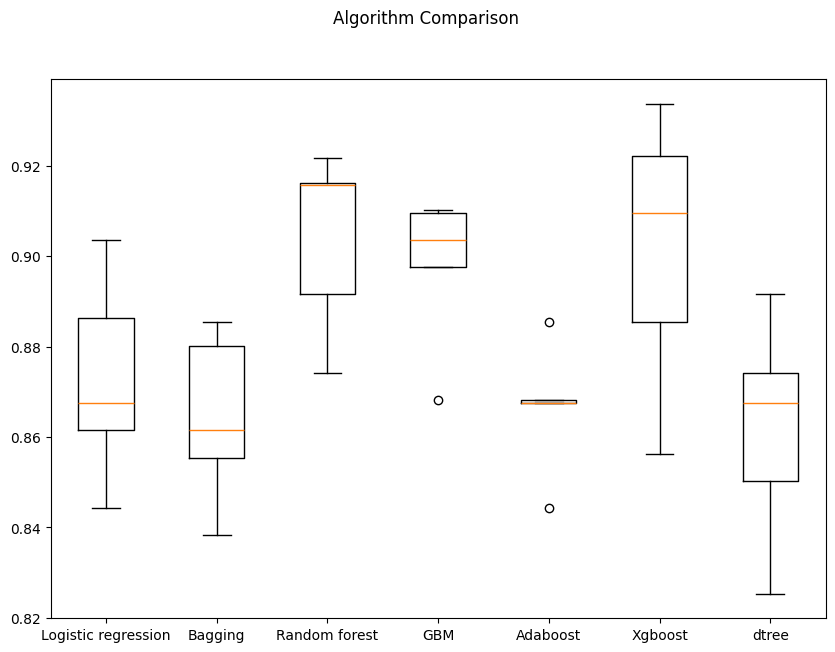

In [ ]:
# Plotting boxplots for CV scores of all models defined above
fig = plt.figure(figsize=(10, 7))

fig.suptitle("Algorithm Comparison")
ax = fig.add_subplot(111)

plt.boxplot(results1)
ax.set_xticklabels(names)

plt.show()

* After undersampling, all train recall cv scores are between 86-90% with Decision Tree being the lowest and Random Forest the highest (with XGBoost an extremely close second).
* In validation, recall scores range between 84-90%, with Decision Tree being the lowest and XGBoost the highest.
* The second two top models in validation after XGBoost are Random Forest, and Gradient Boost.
* Discrepancy between measurements narrower across the board between train and validation.

## Hyperparameter Tuning

**Hyperparameter tuning can take a long time to run, so to avoid that time complexity - you can use the following grids, wherever required.**

- For Gradient Boosting:

param_grid = {
    "n_estimators": np.arange(100,150,25),
    "learning_rate": [0.2, 0.05, 1],
    "subsample":[0.5,0.7],
    "max_features":[0.5,0.7]
}

- For Adaboost:

param_grid = {
    "n_estimators": [100, 150, 200],
    "learning_rate": [0.2, 0.05],
    "base_estimator": [DecisionTreeClassifier(max_depth=1, random_state=1), DecisionTreeClassifier(max_depth=2, random_state=1), DecisionTreeClassifier(max_depth=3, random_state=1),
    ]
}

- For Bagging Classifier:

param_grid = {
    'max_samples': [0.8,0.9,1],
    'max_features': [0.7,0.8,0.9],
    'n_estimators' : [30,50,70],
}

- For Random Forest:

param_grid = {
    "n_estimators": [200,250,300],
    "min_samples_leaf": np.arange(1, 4),
    "max_features": [np.arange(0.3, 0.6, 0.1),'sqrt'],
    "max_samples": np.arange(0.4, 0.7, 0.1)
}

- For Decision Trees:

param_grid = {
    'max_depth': np.arange(2,6),
    'min_samples_leaf': [1, 4, 7],
    'max_leaf_nodes' : [10, 15],
    'min_impurity_decrease': [0.0001,0.001]
}

- For Logistic Regression:

param_grid = {'C': np.arange(0.1,1.1,0.1)}

- For XGBoost:

param_grid={
    'n_estimators': [150, 200, 250],
    'scale_pos_weight': [5,10],
    'learning_rate': [0.1,0.2],
    'gamma': [0,3,5],
    'subsample': [0.8,0.9]
}

### Top 4 models by Recall Scores in validation

The following 4 models are chosen for hypertuning based off having the highest Recall scores in validation:

* **XGBoost with Undersampling**: 0.89568345323741
* **Random Forest with Undersampling**: 0.8920863309352518
* **GBM with Oversampling**: 0.8776978417266187
* **XGBoost with Oversampling**: 0.8669064748201439

### XGBoost tuning with undersampled data

##### Find best hyperparameter values

In [ ]:
# Define XGBoost model:
Model = XGBClassifier(random_state=1, eval_metric="logloss")

# Parameter grid to pass to RandomSearchCV:
param_grid={ 'n_estimators': [150, 200, 250], 'scale_pos_weight': [5,10], 'learning_rate': [0.1,0.2], 'gamma': [0,3,5], 'subsample': [0.8,0.9] }

# Call RandomizedSearchCV:
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_iter=10, n_jobs = -1, scoring=scorer, cv=5, random_state=1)

# Fit parameters in RandomizedSearchCV
randomized_cv.fit(X_train_un,y_train_un)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'subsample': 0.9, 'scale_pos_weight': 10, 'n_estimators': 200, 'learning_rate': 0.1, 'gamma': 5} with CV score=0.9290599523843879:


##### Update model

In [ ]:
# Define updated XGB model using best parameters:
tuned_xgb2 = XGBClassifier(
    random_state=1,
    eval_metric="logloss",
    subsample=.9,
    scale_pos_weight=10,
    n_estimators=200,
    learning_rate=.1,
    gamma=5
)

# Fit the updated XGB model on undersampled data:
tuned_xgb2.fit(X_train_un, y_train_un)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=5, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, random_state=1, ...)

##### Check performance

In [ ]:
# Check performance of updated XGB model on undersampled train set:
xgb2_train_perf = model_performance_classification_sklearn(tuned_xgb2, X_train_un, y_train_un)
xgb2_train_perf

,Accuracy,Recall,Precision,F1
0,0.979,1.000,0.960,0.979


In [ ]:
# Check performance of updated XGB model on validation set:
xgb2_val_perf = model_performance_classification_sklearn(tuned_xgb2, X_val, y_val)
xgb2_val_perf

,Accuracy,Recall,Precision,F1
0,0.832,0.921,0.239,0.379


* Recall on validation for the XGB model formed from undersampled data is .921.
* However, low precision indicates this model also identifies a high number of false positives.

### Random Forest tuning with undersampled data



##### Find best hyperparameter values

In [ ]:
# Define Random Forest model:
Model = RandomForestClassifier(random_state=1)

# Parameter grid to pass to RandomSearchCV:
param_grid = { "n_estimators": [200,250,300], "min_samples_leaf": np.arange(1, 4), "max_features": [np.arange(0.3, 0.6, 0.1),'sqrt'], "max_samples": np.arange(0.4, 0.7, 0.1) }

# Call RandomizedSearchCV:
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_iter=10, n_jobs = -1, scoring=scorer, cv=5, random_state=1)

# Fit parameters in RandomizedSearchCV
randomized_cv.fit(X_train_un,y_train_un)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'n_estimators': 250, 'min_samples_leaf': 1, 'max_samples': 0.6, 'max_features': 'sqrt'} with CV score=0.8978140105331505:


##### Update model

In [ ]:
# Define updated Random Forest model using best parameters:
tuned_rf2 = RandomForestClassifier(
    max_features='sqrt',
    random_state=1,
    max_samples=.6,
    n_estimators=250,
    min_samples_leaf=1
)

# Fit the updated Random Forest model on undersampled train data:
tuned_rf2.fit(X_train_un, y_train_un)

RandomForestClassifier(max_samples=0.6, n_estimators=250, random_state=1)

##### Check performance

In [ ]:
# Check the performance of updated Random Forest model on undersampled train set:
rf2_train_perf = model_performance_classification_sklearn(tuned_rf2, X_train_un, y_train_un)
rf2_train_perf

,Accuracy,Recall,Precision,F1
0,0.988,0.977,0.999,0.988


In [ ]:
# Check the performance of updated Random Forest model on validation set:
rf2_val_perf = model_performance_classification_sklearn(tuned_rf2, X_val, y_val)
rf2_val_perf

,Accuracy,Recall,Precision,F1
0,0.944,0.885,0.496,0.636


* Recall is a respectable .885 in validation.
* Precision at .496 also indicates a fair number of false positives are also expected with this model.

### Gradient Boost tuning with oversampled data

#### Find best hyperparameter values

In [ ]:
# Define Gradient Boosting model:
Model = GradientBoostingClassifier(random_state=1)

# Parameter grid to pass to RandomSearchCV:
param_grid = { "n_estimators": np.arange(100,150,25), "learning_rate": [0.2, 0.05, 1], "subsample":[0.5,0.7], "max_features":[0.5,0.7] }

# Call RandomizedSearchCV:
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_iter=10, n_jobs = -1, scoring=scorer, cv=5, random_state=1)

# Fit parameters in RandomizedSearchCV
randomized_cv.fit(X_train_over,y_train_over)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'subsample': 0.7, 'n_estimators': 125, 'max_features': 0.5, 'learning_rate': 1} with CV score=0.9726854410951082:


#### Update model

In [ ]:
# Define updated Gradient Boosting model using best parameters:
tuned_gbm2 = GradientBoostingClassifier(
    max_features=.5,
    random_state=1,
    learning_rate=1,
    n_estimators=125,
    subsample=.7
)

# Fit the updated Gradient Boosting model on oversampled train data:
tuned_gbm2.fit(X_train_over, y_train_over)

GradientBoostingClassifier(learning_rate=1, max_features=0.5, n_estimators=125,
                           random_state=1, subsample=0.7)

#### Check performance

In [ ]:
# Check the performance of updated GB model on oversampled train set:
gbm2_train_perf = model_performance_classification_sklearn(tuned_gbm2, X_train_over, y_train_over)
gbm2_train_perf

,Accuracy,Recall,Precision,F1
0,0.993,0.993,0.994,0.993


In [ ]:
# Check the performance of updated GB model on validation set:
gbm2_val_perf = model_performance_classification_sklearn(tuned_gbm2, X_val, y_val)
gbm2_val_perf

,Accuracy,Recall,Precision,F1
0,0.971,0.845,0.693,0.762


* The tuned Gradient Boost model formed from oversampled data gives a decent recall score of .845.
* Precision is much closer in value, indicating fewer false positives with this model than the tuned XGBoost and Random Forest models formed from undersampled data.

### XGBoost with oversampled data

#### Find best hyperparameter values

In [ ]:
# Define XGBoost model:
Model = XGBClassifier(random_state=1, eval_metric="logloss")

# Parameter grid to pass to RandomSearchCV:
param_grid={ 'n_estimators': [150, 200, 250], 'scale_pos_weight': [5,10], 'learning_rate': [0.1,0.2], 'gamma': [0,3,5], 'subsample': [0.8,0.9] }

# Call RandomizedSearchCV:
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_iter=10, n_jobs = -1, scoring=scorer, cv=5, random_state=1)

# Fit parameters in RandomizedSearchCV
randomized_cv.fit(X_train_over,y_train_over)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'subsample': 0.9, 'scale_pos_weight': 10, 'n_estimators': 200, 'learning_rate': 0.2, 'gamma': 0} with CV score=0.9959769935987322:


#### Update model

In [ ]:
# Define updated XGB model using best parameters:
tuned_xgb3 = XGBClassifier(
    random_state=1,
    eval_metric="logloss",
    subsample=.9,
    scale_pos_weight=10,
    n_estimators=200,
    learning_rate=.2,
    gamma=0
)

# Fit the model on oversampled train data:
tuned_xgb3.fit(X_train_over, y_train_over)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=0, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.2, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, random_state=1, ...)

#### Check performance

In [ ]:
# Check performance of updated XGB model on oversampled train set:
xgb3_train_perf = model_performance_classification_sklearn(tuned_xgb3, X_train_over, y_train_over)
xgb3_train_perf

,Accuracy,Recall,Precision,F1
0,1.000,1.000,1.000,1.000


Perfect 1.0 scores across all performance metrics indicates overfitting to train data.

In [ ]:
# Check performance of updated XGB model on validation set:
xgb3_val_perf = model_performance_classification_sklearn(tuned_xgb3, X_val, y_val)
xgb3_val_perf

,Accuracy,Recall,Precision,F1
0,0.985,0.871,0.855,0.863


* Despite the overfitting indicators for train, the tuned XGB model formed from oversampled data maintains a respectable .871 recall score.
* Relatively close precision and F1 scores (to recall) indicate this model also maintains a good balance between correctly classifying positive cases without too many false positives.

## Model performance comparison and choosing the final model

### Train performance comparison

In [ ]:
# training performance comparison

models_train_comp_df = pd.concat(
    [
        xgb2_train_perf.T,
        xgb3_train_perf.T,
        gbm2_train_perf.T,
        rf2_train_perf.T
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "XGBoost tuned with undersampled data",
    "XGBoost tuned with oversampled data",
    "Random forest tuned with undersampled data",
    "Gradient Boosting tuned with oversampled data"
]
print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,XGBoost tuned with undersampled data,XGBoost tuned with oversampled data,Random forest tuned with undersampled data,Gradient Boosting tuned with oversampled data
Accuracy,0.979,1.000,0.993,0.988
Recall,1.000,1.000,0.993,0.977
Precision,0.960,1.000,0.994,0.999
F1,0.979,1.000,0.993,0.988


### Validation performance comparison

In [ ]:
# validation performance comparison

models_val_comp_df = pd.concat(
    [
        xgb2_val_perf.T,
        xgb3_val_perf.T,
        gbm2_val_perf.T,
        rf2_val_perf.T
    ],
    axis=1,
)
models_val_comp_df.columns = [
    "XGBoost tuned with undersampled data",
    "XGBoost tuned with oversampled data",
    "Random forest tuned with undersampled data",
    "Gradient Boosting tuned with oversampled data"
]
print("Validation performance comparison:")
models_val_comp_df

Validation performance comparison:


,XGBoost tuned with undersampled data,XGBoost tuned with oversampled data,Random forest tuned with undersampled data,Gradient Boosting tuned with oversampled data
Accuracy,0.832,0.985,0.971,0.944
Recall,0.921,0.871,0.845,0.885
Precision,0.239,0.855,0.693,0.496
F1,0.379,0.863,0.762,0.636


* With a recall of .921, the tuned XGBoost model formed with undersampled data maximizes the identification of failures.
  * This model also has the lowest accuracy,  precision and F1 scores across the four models; the precision score of .239 indicates a much higher liklihood of false positives.

* The tuned Gradient Boost model formed with oversampled data has the second highest recall score (.885) of the 4 models.
  * The cost of false positives is comparatively lower with this model than with the XGBoost model, with a higher precision at .496.

* The tuned XGBoost model formed with oversampled data has the third highest recall of the four models in validation, with the highest balance across the other performance metrics.

### Final Model Selection:

The overall objective is to reduce maintenance costs.  As replacement and repair is stated to be significantly more costly than inspection, recall has been identified as the performance metric to prioritize.  

Of the 4 models selected for hypertuning, the **Tuned XGBoost model built with undersampled data (XGB2)** has the highest recall in validation. The pre-tuned XGBoost model also performed highest in recall amongst all other pre-tuned models.

### Test set final performance

In [ ]:
# Check performance of XGB2 model developed from undersampled data:
xgb2_test_perf = model_performance_classification_sklearn(tuned_xgb2, X_test, y_test)
xgb2_test_perf

,Accuracy,Recall,Precision,F1
0,0.834,0.890,0.239,0.376


Performance of the tuned XGB model developed from undersampled data holds on the test data, maintaining a higher recall than on any of the previous models in validation at .89.

## Feature Importances

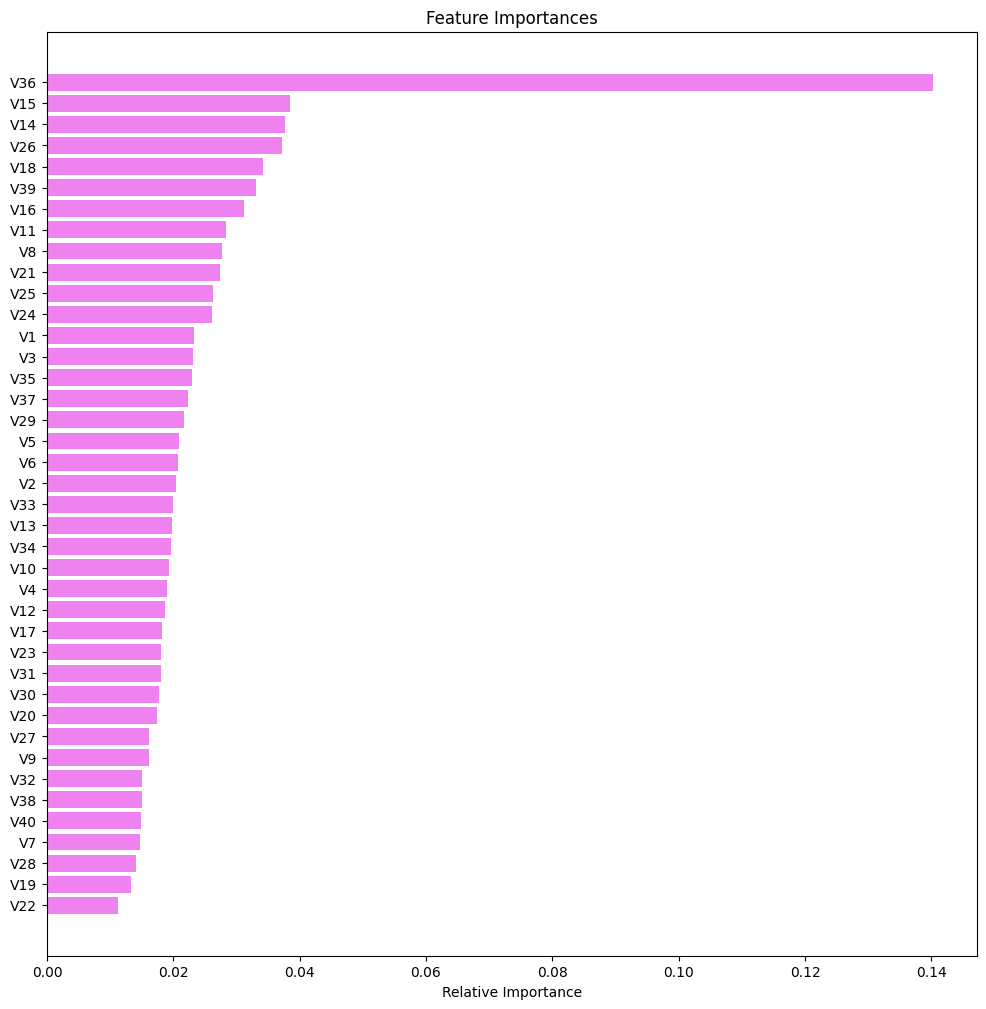

In [ ]:
# Plot feature importance of XGB2:
feature_names = X_train.columns
importances = tuned_xgb2.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12, 12))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

## Pipeline to build the final model


### Establish pipeline for XGB model

In [ ]:
# Create pipeline for XGB2 model:
Pipeline_model = Pipeline([
    ('imputer', SimpleImputer(strategy="median")),
    ('XGBModel', XGBClassifier(random_state=1,
                               eval_metric="logloss",
                               subsample=.9,
                               scale_pos_weight=10,
                               n_estimators=200,
                               learning_rate=.1,
                               gamma=5
                              ))
    ])


### Reset variables for train and test

In [ ]:
# Separate target variable and other variables on train:
X1 = data.drop(columns="Target")
Y1 = data["Target"]

# Separate target and other variables on test:
X_test1 = df_test.drop(columns="Target")
y_test1 = df_test["Target"]

### Impute missing values in train (prepare for undersampling)

In [ ]:
# Treat the missing values in the re-established train set:
imputer = SimpleImputer(strategy="median")
X1 = imputer.fit_transform(X1)

# We don't need to impute missing values in test set as it will be done inside pipeline.

In [ ]:
# Confirm no missing values in train:
pd.DataFrame(X1).isna().values.any()

False

No missing values.

### Complete Undersampling on train

In [ ]:
# Perform undersampling on train:
rus = RandomUnderSampler(random_state=1, sampling_strategy=1)
X1_train_un, y1_train_un = rus.fit_resample(X1, Y1)

### Fit the final XGB model on the reset train (undersampled) data

In [ ]:
# Fit the XGB model on the re-established undersampled train data set:
Pipeline_model.fit(X1_train_un, y1_train_un)

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('XGBModel',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric='logloss',
                               feature_types=None, gamma=5, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=200, n_jobs=None,
                               num_parallel_tree=None, random_state=1, ...))])

### Check performance of final pipeline model on test

In [ ]:
# Check performance of final pipeline model on test:
Pipeline_model_test_perf = model_performance_classification_sklearn(Pipeline_model, X_test1, y_test1)
Pipeline_model_test_perf

,Accuracy,Recall,Precision,F1
0,0.838,0.890,0.244,0.383


* We have generalized performance with the final pipeline model.  
* Recall maintained at .89 in test.

# Business Insights and Conclusions

## Best model and its performance

* The overall objective is to reduce maintenance costs. As replacement and repair is stated to be significantly more costly than inspection, recall has been identified as the performance metric to prioritize.  This essentially means the interest in identifying *the most failures* is prioritized over the cost of inspecting parts falsely identified with failures.

* Of the 4 models selected for hypertuning, the **Tuned XGBoost model developed with undersampled data (XGB2) had the highest recall** in validation, and generalized well in test data with a recall of 89%.

* The cost for higher recall is typically low precision (as noted in the first bullet), which holds true with this model with a 24% precision rate.  This means that there will be some cost associated with false positives (inspections that yield no failure).

## Important features
* The top 12 features in descending order of importance to predicting failures are:
  * V36
  * V15
  * V14
  * V26
  * V18
  * V39
  * V16
  * V11
  * V8
  * V21
  * V25
  * V24

* Of these top 12:
  * V21, V15, and V16 were spotted as having positive correlation with the target in the correlation matrix.

  * V18, V39, V36, and V26 were spotted as having the largest negative correlation with the target in the correlation matrix.

## Additional notes

* In validation testing, the tuned Gradient Boost model formed with oversampled data had the second highest recall score (~89%) after the selected tuned XGBoost model with undersampled data (92%).  It's relatively higher precision value at ~50% (compared with the ~24% precision with the chosen XGBoost model) could temper the cost of unnecessary inspections should that become a concern later.

* In validation, the tuned XGBoost model formed with oversampled data had the third highest recall, with the highest balance across the other performance metrics.  If the cost of false positives becomes really problematic, this model with 87% recall is only slightly less than the Gradient Boost model, but maintains precision at 86%, definitely maintaining high predictive qualities while minimizing false positives.

* Recommend reviewing the actual costs associated with inspection of misidentification of failed parts to assign a numeric value for future assessment of other models if the strategic objective needs to shift.